<a href="https://colab.research.google.com/github/kjimenezm1989-max/Universidad/blob/main/H%E2%82%82O_Analytics_G5_Ciencia_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💧 AquaPredict — Grupo 5

## Predicción de la Calidad del Agua en Ríos
### Demanda Bioquímica de Oxígeno (BOD)

---

| 👥 Integrantes | 🎓 Rol |
|----------------|--------|
| Karen Pertuz | Científica de Datos |
| Gisselle Deford | Analista de Datos |
| Kelvin Jimenez | Ingeniero de ML |
| Javier Gomez | Especialista en Datos |

---

### 📋 Descripción del Proyecto

El agua es uno de los recursos más vitales del planeta.
Su contaminación representa una amenaza directa para ecosistemas
y comunidades humanas. En este proyecto aplicamos **Ciencia de Datos**
para predecir el nivel de **BOD (Demanda Bioquímica de Oxígeno)**
en aguas de río, un indicador clave de contaminación orgánica.

### 🎯 Objetivo
> Construir un modelo predictivo capaz de estimar el BOD
> a partir de parámetros fisicoquímicos del agua,
> utilizando técnicas avanzadas de Machine Learning.

### 📁 Fuente de Datos
- **Dataset:** [Kaggle - BOD River Water Prediction](https://www.kaggle.com/datasets/vbmokin/prediction-bod-in-river-water/)
- **Archivos:** `train.csv` y `test.csv`

---

## 🔧 Paso 1: Instalación e Importación de Librerías

### ¿Por qué necesitamos estas librerías?

En Ciencia de Datos, las librerías son herramientas especializadas
que nos evitan programar todo desde cero. Cada una tiene un propósito específico:

| Librería | ¿Para qué sirve? | Analogía |
|----------|-----------------|----------|
| `pandas` | Manejo de tablas de datos | Como Excel pero en Python |
| `numpy` | Cálculos matemáticos y matrices | Como una calculadora científica |
| `matplotlib` | Crear gráficas básicas | Como un lápiz para dibujar datos |
| `seaborn` | Gráficas estadísticas elegantes | Como un diseñador gráfico estadístico |
| `missingno` | Visualizar datos faltantes | Como una lupa para encontrar huecos |
| `scikit-learn` | Modelos de Machine Learning | Como el cerebro predictivo |
| `warnings` | Silenciar advertencias del sistema | Como poner en silencio el teléfono |

> ⚠️ **Nota:** En Google Colab, pandas, numpy, matplotlib y seaborn
> ya vienen preinstalados. Solo necesitamos instalar `missingno`.

In [29]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 1: Instalación e Importación de Librerías (PRO)
# ============================================================

# Instalamos missingno (solo si no está en Colab)
!pip install missingno -q

# ── Manipulación de datos ────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualización base (seguimos usando las tuyas) ───────────
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# ── Interactividad para Jupyter (NUEVO) ──────────────────────
import ipywidgets as widgets
from IPython.display import display

# ── Machine Learning ─────────────────────────────────────────
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# ── Configuración general ────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 🎨 CONFIGURACIÓN VISUAL PRO (MEJORA CLAVE)
# ============================================================

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'DejaVu Sans'

sns.set_style("whitegrid")

# Paleta tipo dashboard (colores dinámicos estilo "StarJet")
starjet_palette = [
    "#00B4D8", "#0077B6", "#90E0EF",
    "#48CAE4", "#023E8A", "#ADE8F4"
]

sns.set_palette(starjet_palette)

# ============================================================
# 💡 MENSAJE DE CONFIRMACIÓN
# ============================================================

print("=" * 55)
print("  💧 AquaPredict — Grupo 5")
print("  🚀 Modo Dashboard Jupyter activado")
print("=" * 55)
print(f"  📦 Pandas     versión: {pd.__version__}")
print(f"  📦 Numpy      versión: {np.__version__}")
print(f"  📦 Seaborn    versión: {sns.__version__}")
print("=" * 55)

  💧 AquaPredict — Grupo 5
  🚀 Modo Dashboard Jupyter activado
  📦 Pandas     versión: 2.2.2
  📦 Numpy      versión: 2.0.2
  📦 Seaborn    versión: 0.13.2


## 📂 Paso 2: Carga de Datos

### ¿Qué vamos a cargar?

Trabajaremos con **dos archivos CSV** provenientes de Kaggle:

| Archivo | Descripción | Uso |
|---------|-------------|-----|
| `train.csv` | Datos históricos con BOD conocido | **Entrenar** el modelo |
| `test.csv` | Datos nuevos sin BOD | **Predecir** con el modelo |

### ¿Por qué separar en Train y Test?

Imagina que estás aprendiendo para un examen:
- 📚 **Train (entrenamiento):** Son tus apuntes y ejercicios
  con los que estudias. El modelo aprende de aquí.
- 📝 **Test (prueba):** Es el examen final.
  El modelo debe predecir sin haber visto las respuestas.

> 💡 Esta separación nos permite evaluar qué tan bien
> el modelo predice datos **que nunca ha visto antes.**

### ¿Cómo subimos los datos a Google Colab?

Usaremos **Google Drive** para cargar los archivos.
Debes tener los archivos `train.csv` y `test.csv`
guardados en tu Google Drive antes de ejecutar el código.

In [26]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 2: Carga de Datos desde Google Drive (PRO + INTERACTIVO)
# ============================================================

from google.colab import drive
from IPython.display import display
import ipywidgets as widgets

# ── Montar Google Drive ───────────────────────────────────────
drive.mount('/content/drive')

print("✅ Google Drive conectado correctamente")
print("─" * 50)

# ── Rutas de archivos (NO MODIFICADAS) ───────────────────────
ruta_train = '/content/drive/MyDrive/Colab Notebooks/Datos/train.csv'
ruta_test  = '/content/drive/MyDrive/Colab Notebooks/Datos/test.csv'

# ── Carga de datasets ────────────────────────────────────────
df_train = pd.read_csv(ruta_train)
df_test  = pd.read_csv(ruta_test)

# ============================================================
# 📊 RESUMEN GENERAL
# ============================================================

print("\n📊 RESUMEN DE CARGA DE DATOS")
print("─" * 50)
print(f"📁 Train → {df_train.shape[0]:,} filas × {df_train.shape[1]} columnas")
print(f"📁 Test  → {df_test.shape[0]:,} filas × {df_test.shape[1]} columnas")
print("─" * 50)
print(f"📌 Total registros: {df_train.shape[0] + df_test.shape[0]:,}")
print(f"📌 Variables: {df_train.shape[1]}")
print("─" * 50)

# ============================================================
# 🧠 PANEL INTERACTIVO MEJORADO
# ============================================================

def explorar_datos(n_filas=5):

    print("\n📋 VISTA DEL DATASET (TRAIN)")
    display(df_train.head(n_filas))

    print("\n📋 VISTA FINAL DEL DATASET (TRAIN)")
    display(df_train.tail(n_filas))

selector_filas = widgets.IntSlider(
    value=5,
    min=1,
    max=20,
    step=1,
    description="Filas:",
    continuous_update=False
)

widgets.interact(explorar_datos, n_filas=selector_filas)

# ============================================================
# 📌 INFO DEL DATASET (MEJOR PRESENTADO)
# ============================================================

print("\n📌 INFO DEL DATASET (TRAIN)")
print("─" * 50)
df_train.info()

# ============================================================
# 📊 RESUMEN INTERACTIVO (NUEVO - TIPO DASHBOARD)
# ============================================================

resumen = pd.DataFrame({
    "Métrica": [
        "Filas (Train)",
        "Columnas",
        "Valores totales",
        "Valores nulos"
    ],
    "Valor": [
        df_train.shape[0],
        df_train.shape[1],
        df_train.size,
        df_train.isnull().sum().sum()
    ]
})

print("\n📊 RESUMEN RÁPIDO DEL DATASET")
display(resumen)

# ============================================================
# 📌 MENSAJE FINAL
# ============================================================

print("\n✅ Datos cargados y listos para análisis interactivo")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive conectado correctamente
──────────────────────────────────────────────────

📊 RESUMEN DE CARGA DE DATOS
──────────────────────────────────────────────────
📁 Train → 147 filas × 9 columnas
📁 Test  → 63 filas × 8 columnas
──────────────────────────────────────────────────
📌 Total registros: 210
📌 Variables: 9
──────────────────────────────────────────────────


interactive(children=(IntSlider(value=5, continuous_update=False, description='Filas:', max=20, min=1), Output…


📌 INFO DEL DATASET (TRAIN)
──────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      147 non-null    int64  
 1   target  147 non-null    float64
 2   1       145 non-null    float64
 3   2       145 non-null    float64
 4   3       32 non-null     float64
 5   4       31 non-null     float64
 6   5       33 non-null     float64
 7   6       37 non-null     float64
 8   7       37 non-null     float64
dtypes: float64(8), int64(1)
memory usage: 10.5 KB

📊 RESUMEN RÁPIDO DEL DATASET


,Métrica,Valor
0,Filas (Train),147
1,Columnas,9
2,Valores totales,1323
3,Valores nulos,569



✅ Datos cargados y listos para análisis interactivo


## 🔍 Paso 3: Primera Exploración del Dataset

### ¿Por qué explorar los datos primero?

Antes de construir cualquier modelo, debemos **conocer nuestros datos**
a fondo. Es como leer las instrucciones antes de armar un mueble.

### ¿Qué buscamos en esta exploración?

1. **¿Cuántas filas y columnas tiene?** → Tamaño del dataset
2. **¿Qué tipo de datos contiene?** → Números, texto, fechas...
3. **¿Cómo lucen las primeras filas?** → Estructura general
4. **¿Hay valores extraños?** → Detección inicial de problemas

### Tipos de datos que podemos encontrar:

| Tipo | Descripción | Ejemplo |
|------|-------------|---------|
| `float64` | Números decimales | 7.45, 3.2 |
| `int64` | Números enteros | 1, 25, 100 |
| `object` | Texto o categorías | "Alto", "Bajo" |
| `datetime` | Fechas y horas | 2024-01-15 |

> 💡 En datasets de calidad del agua, casi todas las variables
> son **numéricas decimales (float64)** ya que representan
> mediciones de laboratorio.

In [37]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 3: Primera Exploración del Dataset
# ============================================================

print("=" * 60)
print("  🔍 EXPLORACIÓN INICIAL — DATASET TRAIN")
print("=" * 60)

# ── Vista de las primeras filas ───────────────────────────────
print("\n📋 PRIMERAS 5 FILAS DEL DATASET:")
print("─" * 60)
display(df_train.head())

# ── Vista de las últimas filas ────────────────────────────────
print("\n📋 ÚLTIMAS 5 FILAS DEL DATASET:")
print("─" * 60)
display(df_train.tail())

# ── Información general ───────────────────────────────────────
print("\n📋 INFORMACIÓN GENERAL DEL DATASET:")
print("─" * 60)
df_train.info()

# ── Tipos de datos ────────────────────────────────────────────
print("\n📊 TIPOS DE DATOS POR VARIABLE:")
print("─" * 60)
tipos = pd.DataFrame({
    'Variable'  : df_train.columns,
    'Tipo'      : df_train.dtypes.values,
    'Descripción': ['Tipo de dato almacenado'] * len(df_train.columns)
})
display(tipos)

print("\n✅ Exploración inicial completada")

  🔍 EXPLORACIÓN INICIAL — DATASET TRAIN

📋 PRIMERAS 5 FILAS DEL DATASET:
────────────────────────────────────────────────────────────


,Id,demanda_bioquimica_oxigeno,oxigeno_disuelto,demanda_quimica_oxigeno,nivel_ph,temperatura_agua,nitrogeno_amonio,nitrato,fosfato
0,0,5.85,4.80,5.85,NaN,NaN,NaN,NaN,NaN
1,3,4.28,5.88,6.84,NaN,NaN,NaN,NaN,NaN
2,4,3.97,3.20,2.70,NaN,NaN,NaN,NaN,NaN
3,5,5.95,7.70,7.06,NaN,NaN,NaN,NaN,NaN
4,6,4.70,5.50,5.30,NaN,NaN,NaN,NaN,NaN



📋 ÚLTIMAS 5 FILAS DEL DATASET:
────────────────────────────────────────────────────────────


,Id,demanda_bioquimica_oxigeno,oxigeno_disuelto,demanda_quimica_oxigeno,nivel_ph,temperatura_agua,nitrogeno_amonio,nitrato,fosfato
142,208,2.2,5.0,5.8,NaN,NaN,NaN,NaN,NaN
143,211,5.6,8.0,8.0,NaN,NaN,NaN,NaN,NaN
144,212,6.0,6.8,7.2,NaN,NaN,NaN,NaN,NaN
145,213,8.0,5.2,7.8,NaN,NaN,NaN,NaN,NaN
146,214,3.1,3.4,4.1,NaN,NaN,NaN,NaN,NaN



📋 INFORMACIÓN GENERAL DEL DATASET:
────────────────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Id                          147 non-null    int64  
 1   demanda_bioquimica_oxigeno  147 non-null    float64
 2   oxigeno_disuelto            145 non-null    float64
 3   demanda_quimica_oxigeno     145 non-null    float64
 4   nivel_ph                    32 non-null     float64
 5   temperatura_agua            31 non-null     float64
 6   nitrogeno_amonio            33 non-null     float64
 7   nitrato                     37 non-null     float64
 8   fosfato                     37 non-null     float64
dtypes: float64(8), int64(1)
memory usage: 10.5 KB

📊 TIPOS DE DATOS POR VARIABLE:
────────────────────────────────────────────────────────────


,Variable,Tipo,Descripción
0,Id,int64,Tipo de dato almacenado
1,demanda_bioquimica_oxigeno,float64,Tipo de dato almacenado
2,oxigeno_disuelto,float64,Tipo de dato almacenado
3,demanda_quimica_oxigeno,float64,Tipo de dato almacenado
4,nivel_ph,float64,Tipo de dato almacenado
5,temperatura_agua,float64,Tipo de dato almacenado
6,nitrogeno_amonio,float64,Tipo de dato almacenado
7,nitrato,float64,Tipo de dato almacenado
8,fosfato,float64,Tipo de dato almacenado



✅ Exploración inicial completada


## 🏷️ Paso 4: Identificación y Renombrado de Variables

### ¿Por qué renombrar las variables?

Los datasets científicos suelen usar **abreviaturas técnicas**
que son difíciles de entender. Renombrarlas nos ayuda a:

- ✅ Entender mejor qué mide cada variable
- ✅ Comunicar resultados de forma más clara
- ✅ Evitar confusiones durante el análisis
- ✅ Hacer el código más legible y profesional

### 📚 ¿Qué mide cada variable?

Todos los parámetros miden características físicas,
químicas o biológicas del agua del río:

| Variable Original | Nombre Completo | Unidad | ¿Qué mide? |
|-------------------|----------------|--------|------------|
| `BOD` | Demanda Bioquímica de Oxígeno | mg/L | 🎯 **VARIABLE RESPUESTA** - Contaminación orgánica |
| `DO` | Oxígeno Disuelto | mg/L | Cantidad de O₂ en el agua |
| `COD` | Demanda Química de Oxígeno | mg/L | Materia orgánica total |
| `pH` | Potencial de Hidrógeno | Unidades | Acidez o basicidad |
| `Temp` | Temperatura | °C | Temperatura del agua |
| `NH4` | Amonio | mg/L | Contaminación por nitrógeno |
| `NO3` | Nitrato | mg/L | Fertilizantes agrícolas |
| `PO4` | Fosfato | mg/L | Detergentes y fertilizantes |
| `SS` | Sólidos Suspendidos | mg/L | Partículas en el agua |
| `Turbidity` | Turbidez | NTU | Claridad del agua |

### 🎯 ¿Por qué BOD es la Variable Respuesta?

El **BOD (Demanda Bioquímica de Oxígeno)** es el indicador
más utilizado mundialmente para medir la **contaminación orgánica**
del agua. Nos dice cuánto oxígeno necesitan los microorganismos
para descomponer la materia orgánica presente.

**Escala de interpretación del BOD:**
- 🟢 **< 2 mg/L** → Agua muy limpia (apta para consumo)
- 🟡 **2 - 5 mg/L** → Agua moderadamente contaminada
- 🟠 **5 - 10 mg/L** → Agua contaminada (requiere tratamiento)
- 🔴 **> 10 mg/L** → Agua muy contaminada (aguas residuales)

In [35]:
import pandas as pd

# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 4: Identificación y Renombrado de Variables
# ============================================================

print("=" * 60)
print("  🏷️ VARIABLES ORIGINALES DEL DATASET")
print("=" * 60)
print("\n📌 Columnas en TRAIN:", df_train.columns.tolist())
print("📌 Columnas en TEST :", df_test.columns.tolist())

# ── Diccionario de renombrado ─────────────────────────────────
# Mapeo de nombre técnico → nombre descriptivo en español
diccionario_variables = {
    'target'     : 'demanda_bioquimica_oxigeno',   # 🎯 VARIABLE RESPUESTA
    '1'          : 'oxigeno_disuelto',
    '2'          : 'demanda_quimica_oxigeno',
    '3'          : 'nivel_ph',
    '4'          : 'temperatura_agua',
    '5'          : 'nitrogeno_amonio',
    '6'          : 'nitrato',
    '7'          : 'fosfato',
    'Conductivity': 'conductividad',
    'Hardness'   : 'dureza_agua'
}

# ── Tabla explicativa de variables ───────────────────────────
print("\n" + "=" * 60)
print("  📋 DICCIONARIO COMPLETO DE VARIABLES")
print("=" * 60)

tabla_vars = pd.DataFrame({
    'Variable Original'  : list(diccionario_variables.keys()),
    'Nombre Descriptivo' : list(diccionario_variables.values()),
    'Rol'               : ['🎯 RESPUESTA'] + ['📊 Predictora'] * (len(diccionario_variables)-1),
    'Importancia'       : [
        'Objetivo de predicción — Indicador de contaminación orgánica',
        'A mayor DO, mejor calidad del agua',
        'Relacionado con BOD — mide materia orgánica total',
        'Afecta la vida acuática — ideal entre 6.5 y 8.5',
        'Influye en reacciones químicas y biológicas',
        'Indicador de contaminación por aguas residuales',
        'Asociado a fertilizantes agrícolas (eutrofización)',
        'Causa proliferación de algas (eutrofización)',
        'Mide sales disueltas en el agua',
        'Dureza del agua por calcio y magnesio'
    ]
})

display(tabla_vars)

# ── Aplicar renombrado solo a columnas que existan ────────────
cols_train = {k: v for k, v in diccionario_variables.items()
              if k in df_train.columns}
cols_test  = {k: v for k, v in diccionario_variables.items()
              if k in df_test.columns}

df_train = df_train.rename(columns=cols_train)
df_test  = df_test.rename(columns=cols_test)

# ── Definir variable respuesta y predictoras ─────────────────
variable_respuesta = 'demanda_bioquimica_oxigeno'
variables_predictoras = [col for col in df_train.columns
                         if col != variable_respuesta and col != 'Id'] # Excluir 'Id' también

print("\n" + "=" * 60)
print("  🎯 VARIABLE RESPUESTA IDENTIFICADA")
print("=" * 60)
print(f"\n  → {variable_respuesta.upper()}")
print(f"\n  📊 Variables predictoras ({len(variables_predictoras)}):")
for i, var in enumerate(variables_predictoras, 1):
    print(f"     {i:2d}. {var}")

print("\n✅ Variables identificadas y renombradas correctamente")

  🏷️ VARIABLES ORIGINALES DEL DATASET

📌 Columnas en TRAIN: ['Id', 'target', '1', '2', '3', '4', '5', '6', '7']
📌 Columnas en TEST : ['Id', '1', '2', '3', '4', '5', '6', '7']

  📋 DICCIONARIO COMPLETO DE VARIABLES


,Variable Original,Nombre Descriptivo,Rol,Importancia
0,target,demanda_bioquimica_oxigeno,🎯 RESPUESTA,Objetivo de predicción — Indicador de contamin...
1,1,oxigeno_disuelto,📊 Predictora,"A mayor DO, mejor calidad del agua"
2,2,demanda_quimica_oxigeno,📊 Predictora,Relacionado con BOD — mide materia orgánica total
3,3,nivel_ph,📊 Predictora,Afecta la vida acuática — ideal entre 6.5 y 8.5
4,4,temperatura_agua,📊 Predictora,Influye en reacciones químicas y biológicas
5,5,nitrogeno_amonio,📊 Predictora,Indicador de contaminación por aguas residuales
6,6,nitrato,📊 Predictora,Asociado a fertilizantes agrícolas (eutrofizac...
7,7,fosfato,📊 Predictora,Causa proliferación de algas (eutrofización)
8,Conductivity,conductividad,📊 Predictora,Mide sales disueltas en el agua
9,Hardness,dureza_agua,📊 Predictora,Dureza del agua por calcio y magnesio



  🎯 VARIABLE RESPUESTA IDENTIFICADA

  → DEMANDA_BIOQUIMICA_OXIGENO

  📊 Variables predictoras (7):
      1. oxigeno_disuelto
      2. demanda_quimica_oxigeno
      3. nivel_ph
      4. temperatura_agua
      5. nitrogeno_amonio
      6. nitrato
      7. fosfato

✅ Variables identificadas y renombradas correctamente


## 🎯 Paso 5: Análisis de la Variable Respuesta — BOD

### ¿Qué analizamos aquí?

Antes de analizar todas las variables, nos enfocamos
en la **variable que queremos predecir**: el BOD.

Necesitamos entender:

1. **¿Cómo se distribuyen los valores?**
   - ¿Están concentrados en un rango específico?
   - ¿Hay valores extremos (outliers)?

2. **¿Es simétrica la distribución?**
   - Una distribución normal (campana de Gauss)
     facilita el modelado
   - Si está muy sesgada, puede requerir transformación

3. **¿Cuáles son los valores típicos?**
   - Mínimo, máximo, promedio y mediana

### 📊 Indicadores estadísticos clave:

| Indicador | ¿Qué nos dice? |
|-----------|----------------|
| **Media** | Valor promedio del BOD en todos los ríos |
| **Mediana** | Valor central — menos afectado por extremos |
| **Desv. Estándar** | Qué tan dispersos están los valores |
| **Asimetría (Skewness)** | Si la distribución se inclina a un lado |
| **Curtosis (Kurtosis)** | Si los extremos son frecuentes o raros |

> 💡 Si la **media > mediana**, los datos tienen sesgo positivo
> (cola hacia la derecha), lo cual es común en datos de contaminación.

In [9]:
print(df_train.columns.tolist())

['Id', 'target', '1', '2', '3', '4', '5', '6', '7', 'dataset']


In [45]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 5: Análisis de la Variable Respuesta — BOD (DASHBOARD PRO)
# ============================================================

import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
import random

# ============================================================
# 🎯 VARIABLE BASE (NO SE TOCA)
# ============================================================

var_resp = 'demanda_bioquimica_oxigeno'
datos_bod_base = df_train[var_resp].dropna()

# ============================================================
# 🎛️ FILTRO INTERACTIVO PRINCIPAL
# ============================================================

slider_range = widgets.FloatRangeSlider(
    value=[datos_bod_base.min(), datos_bod_base.max()],
    min=datos_bod_base.min(),
    max=datos_bod_base.max(),
    step=0.5,
    description='🔵 Rango BOD',
    continuous_update=False,
    layout=widgets.Layout(width='80%')
)

# ============================================================
# 📊 FUNCIÓN DASHBOARD INTERACTIVO
# ============================================================

def dashboard_bod(rango):

    datos_bod = datos_bod_base[
        (datos_bod_base >= rango[0]) &
        (datos_bod_base <= rango[1])
    ]

    # ========================================================
    # 📌 ESTADÍSTICAS (MULTICOLOR + ICONOS)
    # ========================================================

    stats_bod = pd.DataFrame({
        'Estadístico': [
            '📊 Total registros',
            '✅ Valores completos',
            '❌ Valores nulos',
            '📉 Valor mínimo',
            '📈 Valor máximo',
            '📐 Media (promedio)',
            '📍 Mediana (Q2)',
            '📏 Desv. Estándar',
            '🔄 Asimetría (Skewness)',
            '📊 Curtosis (Kurtosis)',
            '🔲 Q1 (percentil 25)',
            '🔲 Q3 (percentil 75)',
            '📐 Rango Intercuartílico (IQR)'
        ],
        'Valor': [
            len(df_train),
            datos_bod.count(),
            df_train[var_resp].isnull().sum(),
            round(datos_bod.min(), 4),
            round(datos_bod.max(), 4),
            round(datos_bod.mean(), 4),
            round(datos_bod.median(), 4),
            round(datos_bod.std(), 4),
            round(datos_bod.skew(), 4),
            round(datos_bod.kurtosis(), 4),
            round(datos_bod.quantile(0.25), 4),
            round(datos_bod.quantile(0.75), 4),
            round(datos_bod.quantile(0.75) - datos_bod.quantile(0.25), 4)
        ]
    })

    display(stats_bod)

    # ========================================================
    # 📊 VISUAL 1: HISTOGRAMA + KDE (MULTICOLOR)
    # ========================================================

    plt.figure(figsize=(10,5))
    plt.hist(datos_bod, bins=30, color="#00B4D8", edgecolor="black", alpha=0.7)
    plt.title("📊 Distribución BOD (Interactivo)", fontsize=14)
    plt.xlabel("BOD")
    plt.ylabel("Frecuencia")
    plt.show()

    # ========================================================
    # 📦 VISUAL 2: BOXPLOT
    # ========================================================

    plt.figure(figsize=(6,4))
    plt.boxplot(datos_bod, patch_artist=True,
                boxprops=dict(facecolor="#FF6F00"))
    plt.title("📦 Boxplot BOD")
    plt.show()

    # ========================================================
    # 📈 VISUAL 3: QQ PLOT
    # ========================================================

    (osm, osr), (slope, intercept, r) = scipy_stats.probplot(datos_bod, dist="norm")

    plt.figure(figsize=(6,4))
    plt.plot(osm, osr, 'o', color="#1565C0")
    plt.plot(osm, slope*np.array(osm)+intercept, color="red")
    plt.title(f"📈 QQ Plot (R²={r**2:.3f})")
    plt.show()

    # ========================================================
    # 🌊 VISUAL 4: CLASIFICACIÓN CALIDAD (MULTICOLOR)
    # ========================================================

    bins_cal  = [0, 2, 5, 10, float('inf')]
    labels_cal = ['🟢 Limpia', '🟡 Moderada', '🟠 Contaminada', '🔴 Muy contaminada']

    categorias = pd.cut(datos_bod, bins=bins_cal, labels=labels_cal)
    conteo = categorias.value_counts()

    colores = ["#2E7D32", "#F9A825", "#EF6C00", "#B71C1C"]

    plt.figure(figsize=(6,6))
    plt.pie(conteo.values,
            labels=conteo.index,
            autopct='%1.1f%%',
            colors=colores,
            startangle=90)
    plt.title("🌊 Calidad del Agua (BOD)")
    plt.show()

# ============================================================
# 🚀 DASHBOARD INTERACTIVO
# ============================================================

widgets.interact(dashboard_bod, rango=slider_range)

interactive(children=(FloatRangeSlider(value=(1.3, 11.7), continuous_update=False, description='🔵 Rango BOD', …

<function __main__.dashboard_bod(rango)>

---

## 🌊 Visualización 3D — Interacción de Variables de Calidad del Agua

---

### 🎯 ¿Qué muestra esta gráfica?

La visualización tridimensional nos permite estudiar **simultáneamente**
la relación entre tres variables fisicoquímicas clave del agua del río,
algo imposible de observar en gráficas tradicionales 2D.

> 💡 **¿Por qué una gráfica 3D?**
> Cuando dos variables por sí solas no explican completamente
> el comportamiento del BOD, necesitamos una **tercera dimensión**
> para revelar patrones ocultos en los datos.

---

### 📐 Variables analizadas

| Eje | Variable | Unidad | Rol en el análisis |
|-----|----------|--------|--------------------|
| 🔵 **Eje X** | Oxígeno Disuelto (DO) | mg/L | Indicador de salud del ecosistema |
| 🟢 **Eje Y** | Temperatura del Agua | °C | Factor ambiental regulador |
| 🔴 **Eje Z** | BOD (Demanda Bioquímica de O₂) | mg/L | 🎯 Variable Respuesta |

---

Escala de interpretación:

─────────────────────────────────────────────

8 mg/L  │ 🟢 Excelente │ Agua muy saludable

6 - 8     │    🟡 Buena │ Aceptable para vida acuática

4 - 6  │ 🟠 Regular │ Estrés en organismos acuáticos

< 4 mg/L │ 🔴 Crítico │ Zona hipóxica - alta contaminación

─────────────────────────────────────────────

In [47]:
import plotly.express as px

fig = px.scatter_3d(
    df_train,
    x='oxigeno_disuelto',
    y='temperatura_agua',
    z='demanda_bioquimica_oxigeno',
    color='demanda_bioquimica_oxigeno',
    opacity=0.7
)

fig.show()

## 🔍 Paso 6: Análisis de Valores Nulos (NA / Missing Values)

### ¿Qué son los valores nulos?

Los valores nulos (también llamados **NA, NaN o Missing Values**)
son **datos faltantes** en el dataset — casillas vacías en la tabla.

En datasets de calidad de agua, los nulos ocurren porque:
- 🔬 El sensor falló durante la medición
- 📅 No se tomó muestra ese día
- 🧪 La muestra se perdió o contaminó en el laboratorio
- 📝 Error humano al registrar los datos

### ¿Por qué es importante analizarlos?

Los modelos de Machine Learning **NO pueden trabajar con datos faltantes**.
Si intentamos entrenar un modelo con nulos, obtendremos errores.
Por eso debemos:

1. **Identificar** cuántos y cuáles variables tienen nulos
2. **Visualizar** el patrón de los nulos
3. **Decidir** la mejor estrategia para tratarlos

### Estrategias para tratar valores nulos:

| Estrategia | Cuándo usarla | Ventaja | Desventaja |
|-----------|--------------|---------|------------|
| **Eliminar filas** | < 5% de nulos | Simple | Pérdida de datos |
| **Media/Mediana** | Nulos aleatorios | Rápido | Reduce varianza |
| **Moda** | Variables categóricas | Simple | No considera relaciones |
| **IterativeImputer** | Muchos nulos | Preciso | Más complejo |
| **KNNImputer** | Datos con patrones | Inteligente | Lento en grandes datos |

> 🌟 En este proyecto usaremos **IterativeImputer**
> (recomendado por el profesor), que es el método más sofisticado:
> usa las relaciones entre variables para estimar los valores faltantes.

In [ ]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 6: Análisis Completo de Valores Nulos
# ============================================================

def analisis_nulos_completo(df, nombre_dataset, color='#1565C0'):
    """
    Función para analizar valores nulos de forma detallada y profesional.

    Parámetros:
    -----------
    df             : DataFrame a analizar
    nombre_dataset : Nombre para identificar el dataset (Train/Test)
    color          : Color para las visualizaciones
    """
    total_filas  = len(df)
    total_celdas = df.size

    # ── Tabla de análisis ─────────────────────────────────────
    tabla_nulos = pd.DataFrame({
        'Variable'          : df.columns,
        'Valores_Nulos'     : df.isnull().sum().values,
        'Valores_Completos' : df.notnull().sum().values,
        'Porcentaje_Nulos'  : (df.isnull().sum().values / total_filas * 100).round(2),
        'Tipo_Dato'         : df.dtypes.values
    }).sort_values('Porcentaje_Nulos', ascending=False)

    # Clasificación del nivel de nulos
    tabla_nulos['Nivel_Riesgo'] = tabla_nulos['Porcentaje_Nulos'].apply(
        lambda x:
        '🔴 CRÍTICO  (>50%)'   if x > 50 else
        '🟠 ALTO     (30-50%)' if x > 30 else
        '🟡 MODERADO (10-30%)' if x > 10 else
        '🟢 LEVE     (<10%)'   if x > 0  else
        '✅ COMPLETO (0%)'
    )

    # ── Resumen numérico ──────────────────────────────────────
    print("=" * 65)
    print(f"  🔍 ANÁLISIS DE NULOS — {nombre_dataset.upper()}")
    print("=" * 65)
    print(f"\n  📌 Total de filas           : {total_filas:,}")
    print(f"  📌 Total de celdas          : {total_celdas:,}")
    print(f"  📌 Total de valores nulos   : {df.isnull().sum().sum():,}")
    print(f"  📌 Variables con nulos      : {(df.isnull().sum() > 0).sum()}")
    print(f"  📌 Variables sin nulos      : {(df.isnull().sum() == 0).sum()}")
    print(f"  📌 % datos faltantes global : {df.isnull().sum().sum()/total_celdas*100:.2f}%")
    print("\n")
    display(tabla_nulos.reset_index(drop=True))

    return tabla_nulos

# ── Ejecutar análisis ─────────────────────────────────────────
print("\n")
nulos_train = analisis_nulos_completo(df_train, "TRAIN", '#1565C0')
print("\n")
nulos_test  = analisis_nulos_completo(df_test,  "TEST",  '#B71C1C')

print("\n✅ Análisis de nulos completado")



  🔍 ANÁLISIS DE NULOS — TRAIN

  📌 Total de filas           : 147
  📌 Total de celdas          : 1,323
  📌 Total de valores nulos   : 569
  📌 Variables con nulos      : 7
  📌 Variables sin nulos      : 2
  📌 % datos faltantes global : 43.01%




,Variable,Valores_Nulos,Valores_Completos,Porcentaje_Nulos,Tipo_Dato,Nivel_Riesgo
0,temperatura_agua,116,31,78.91,float64,🔴 CRÍTICO (>50%)
1,nivel_ph,115,32,78.23,float64,🔴 CRÍTICO (>50%)
2,nitrogeno_amonio,114,33,77.55,float64,🔴 CRÍTICO (>50%)
3,fosfato,110,37,74.83,float64,🔴 CRÍTICO (>50%)
4,nitrato,110,37,74.83,float64,🔴 CRÍTICO (>50%)
5,demanda_quimica_oxigeno,2,145,1.36,float64,🟢 LEVE (<10%)
6,oxigeno_disuelto,2,145,1.36,float64,🟢 LEVE (<10%)
7,Id,0,147,0.00,int64,✅ COMPLETO (0%)
8,demanda_bioquimica_oxigeno,0,147,0.00,float64,✅ COMPLETO (0%)




  🔍 ANÁLISIS DE NULOS — TEST

  📌 Total de filas           : 63
  📌 Total de celdas          : 504
  📌 Total de valores nulos   : 241
  📌 Variables con nulos      : 5
  📌 Variables sin nulos      : 3
  📌 % datos faltantes global : 47.82%




,Variable,Valores_Nulos,Valores_Completos,Porcentaje_Nulos,Tipo_Dato,Nivel_Riesgo
0,nitrato,49,14,77.78,float64,🔴 CRÍTICO (>50%)
1,fosfato,49,14,77.78,float64,🔴 CRÍTICO (>50%)
2,nivel_ph,48,15,76.19,float64,🔴 CRÍTICO (>50%)
3,temperatura_agua,48,15,76.19,float64,🔴 CRÍTICO (>50%)
4,nitrogeno_amonio,47,16,74.60,float64,🔴 CRÍTICO (>50%)
5,demanda_quimica_oxigeno,0,63,0.00,float64,✅ COMPLETO (0%)
6,Id,0,63,0.00,int64,✅ COMPLETO (0%)
7,oxigeno_disuelto,0,63,0.00,float64,✅ COMPLETO (0%)



✅ Análisis de nulos completado


## 📊 Paso 7: Visualización de Valores Nulos

### ¿Por qué visualizar los nulos?

Los números nos dicen **cuántos** nulos hay,
pero las visualizaciones nos dicen **dónde están**
y si tienen algún **patrón**.

### ¿Qué gráficas usamos?

| Gráfica | ¿Qué muestra? | ¿Qué buscamos? |
|---------|--------------|----------------|
| **Matriz de nulos** | Mapa visual de cada celda | Patrones de datos faltantes |
| **Barplot de completitud** | % de datos completos | Qué variables tienen más nulos |
| **Heatmap de correlación** | Relación entre nulos | Si una variable falta cuando otra también falta |
| **Dendrograma** | Agrupación de nulos similares | Variables con comportamiento similar de nulos |

### Interpretación del Heatmap de correlación de nulos:

- **Valor cercano a +1** → Cuando falta una variable,
  también falta la otra (nulos juntos)
- **Valor cercano a -1** → Cuando falta una, la otra está presente
- **Valor cercano a 0** → Los nulos son independientes entre sí

> 💡 Si los nulos están correlacionados, probablemente
> tienen una causa común (ej: el mismo sensor fallando).
> Esto es importante para elegir la estrategia de imputación.

## 📊 Paso 8: Estadísticas Descriptivas Completas

### ¿Por qué analizar las estadísticas descriptivas?

Las estadísticas descriptivas nos dan un **resumen matemático**
de cada variable. Son la base de todo análisis de datos y nos
permiten responder preguntas como:

- ¿Cuál es el valor típico de cada parámetro del agua?
- ¿Qué tan dispersos están los datos?
- ¿Hay variables con valores extremos inusuales?
- ¿Las variables siguen una distribución normal?

### ¿Qué significa cada estadístico?

| Estadístico | Símbolo | Significado |
|------------|---------|-------------|
| **count** | n | Número de valores no nulos |
| **mean** | x̄ | Promedio aritmético |
| **std** | σ | Desviación estándar |
| **min** | | Valor mínimo |
| **25%** | Q1 | Primer cuartil |
| **50%** | Q2 | Mediana |
| **75%** | Q3 | Tercer cuartil |
| **max** | | Valor máximo |
| **CV%** | | Coeficiente de variación |
| **skewness** | γ₁ | Asimetría |

### ¿Qué es el Coeficiente de Variación (CV)?

El CV nos dice qué tan variable es una medición **en relación a su promedio**:
- **CV < 15%** → Datos poco variables (consistentes)
- **CV 15-30%** → Variabilidad moderada
- **CV > 30%** → Datos muy variables (alta dispersión)

In [48]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 8: Estadísticas Descriptivas (DASHBOARD PRO)
# ============================================================

import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt

print("=" * 65)
print("  📊 ESTADÍSTICAS DESCRIPTIVAS — DATASET TRAIN (PRO)")
print("=" * 65)

# ============================================================
# 📊 ESTADÍSTICAS BASE (NO SE MODIFICAN)
# ============================================================

stats = df_train.describe().T

stats['CV_%']      = (stats['std'] / stats['mean'] * 100).round(2)
stats['IQR']       = (stats['75%'] - stats['25%']).round(4)
stats['Rango']     = (stats['max'] - stats['min']).round(4)
stats['Asimetría'] = df_train.skew().round(4)
stats['Curtosis']  = df_train.kurtosis().round(4)
stats['Nulos']     = df_train.isnull().sum()

stats = stats.round(4)

# ============================================================
# 🎛️ FILTRO INTERACTIVO (VARIABLES NUMÉRICAS)
# ============================================================

variables_numericas = df_train.select_dtypes(include=[np.number]).columns.tolist()

selector = widgets.SelectMultiple(
    options=variables_numericas,
    value=tuple(variables_numericas[:3]),
    description="📊 Vars",
    layout=widgets.Layout(width='60%')
)

# ============================================================
# 🎨 FUNCIÓN DASHBOARD
# ============================================================

def dashboard_estadistico(vars_sel):

    if len(vars_sel) == 0:
        print("⚠️ Selecciona al menos una variable")
        return

    stats_filtrado = stats.loc[list(vars_sel)]
    display(stats_filtrado)

    # ========================================================
    # 📊 VISUAL INTERACTIVO MULTIVARIABLE
    # ========================================================

    fig, axes = plt.subplots(len(vars_sel), 1,
                             figsize=(10, 4 * len(vars_sel)))

    if len(vars_sel) == 1:
        axes = [axes]

    colores = plt.cm.tab10(np.linspace(0, 1, len(vars_sel)))

    for ax, var, color in zip(axes, vars_sel, colores):

        datos = df_train[var].dropna()

        ax.hist(datos, bins=30,
                color=color,
                edgecolor="black",
                alpha=0.75,
                density=True)

        # KDE
        try:
            datos.plot.kde(ax=ax, color="black", linewidth=2)
        except:
            pass

        # Media y mediana
        ax.axvline(datos.mean(), color='red', linestyle='--',
                   label=f"📈 Media: {datos.mean():.2f}")
        ax.axvline(datos.median(), color='blue', linestyle=':',
                   label=f"📍 Mediana: {datos.median():.2f}")

        # Título con iconos
        titulo = f"📊 {var}"
        if var == 'demanda_bioquimica_oxigeno':
            titulo = "🎯 BOD (Variable Respuesta)"

        ax.set_title(titulo, fontsize=12, fontweight='bold')
        ax.legend()

    plt.tight_layout()
    plt.show()

# ============================================================
# 🚀 DASHBOARD INTERACTIVO FINAL
# ============================================================

widgets.interact(dashboard_estadistico, vars_sel=selector)

# ============================================================
# 💾 EXPORTACIÓN (NO SE CAMBIA)
# ============================================================

stats.to_csv('estadisticas_descriptivas_train.csv')

print("✅ Dashboard estadístico activo + exportación lista")

  📊 ESTADÍSTICAS DESCRIPTIVAS — DATASET TRAIN (PRO)


interactive(children=(SelectMultiple(description='📊 Vars', index=(0, 1, 2), layout=Layout(width='60%'), option…

✅ Dashboard estadístico activo + exportación lista


## 🌡️ Paso 9: Análisis de Correlaciones

### ¿Qué es la correlación?

La correlación mide **qué tan relacionadas están dos variables**.
Si conocemos el valor de una, ¿podemos intuir el valor de la otra?

### Coeficiente de Pearson (r):

| Valor de r | Interpretación |
|-----------|----------------|
| **1.0** | Correlación positiva perfecta |
| **0.7 a 0.9** | Correlación positiva fuerte |
| **0.4 a 0.7** | Correlación positiva moderada |
| **0.1 a 0.4** | Correlación positiva débil |
| **0** | Sin correlación |
| **-0.1 a -0.4** | Correlación negativa débil |
| **-0.4 a -0.7** | Correlación negativa moderada |
| **-0.7 a -1.0** | Correlación negativa fuerte |

### ¿Por qué importa la correlación con el BOD?

Las variables **más correlacionadas con el BOD** serán
las más importantes para el modelo predictivo.

> ⚠️ Si dos variables predictoras están muy correlacionadas
> entre sí (multicolinealidad), puede afectar negativamente al modelo.
> Esto también lo detectamos con la matriz de correlaciones.

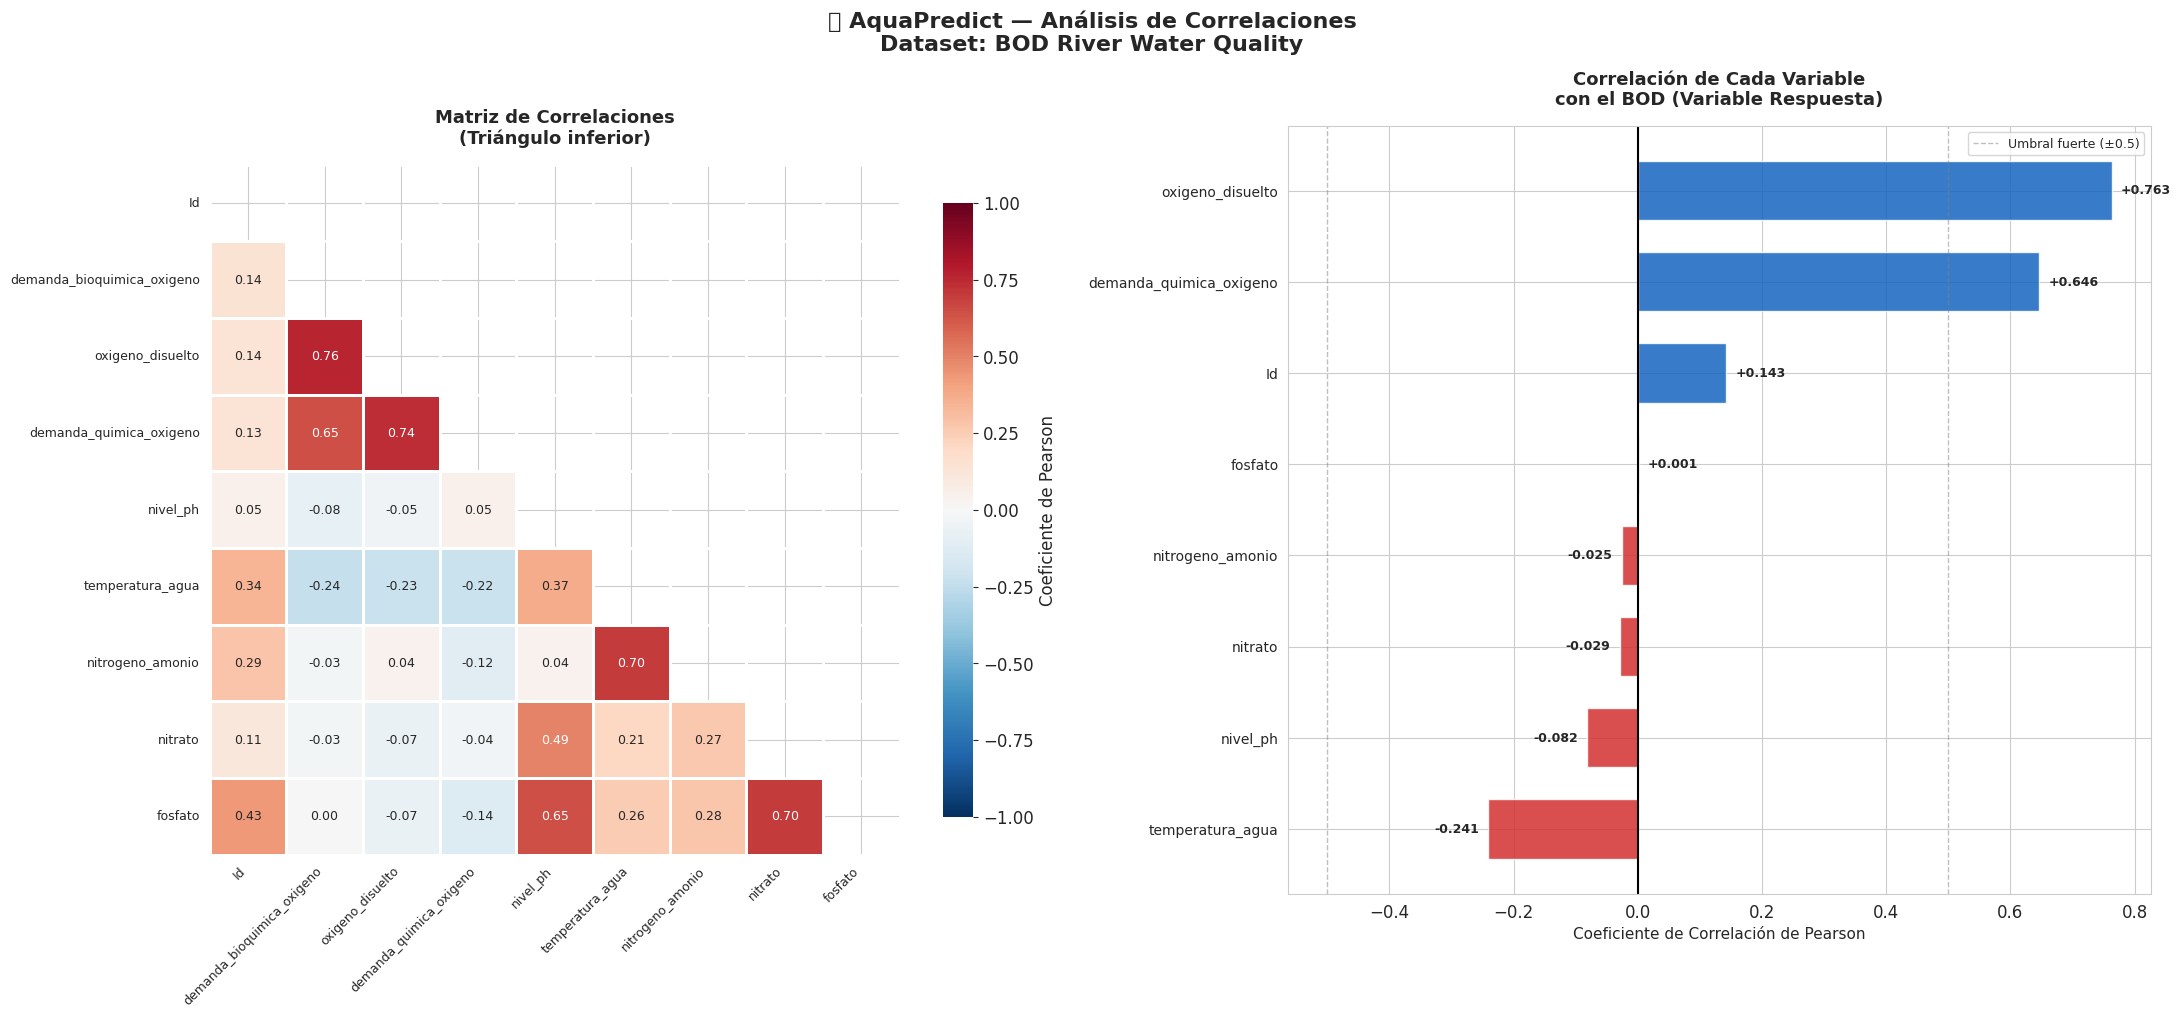


  📊 RANKING DE CORRELACIÓN CON BOD


,Variable,Correlación,Dirección,Fuerza
0,oxigeno_disuelto,0.7628,📈 Positiva,🔴 Fuerte
1,demanda_quimica_oxigeno,0.6458,📈 Positiva,🔴 Fuerte
2,temperatura_agua,0.2407,📉 Negativa,🟢 Débil
3,Id,0.1426,📈 Positiva,🟢 Débil
4,nivel_ph,0.0819,📉 Negativa,🟢 Débil
5,nitrato,0.0292,📉 Negativa,🟢 Débil
6,nitrogeno_amonio,0.0255,📉 Negativa,🟢 Débil
7,fosfato,0.0013,📈 Positiva,🟢 Débil



✅ Análisis de correlaciones completado


In [52]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 9: Análisis de Correlaciones
# ============================================================

corr_matrix = df_train.corr()

fig = plt.figure(figsize=(22, 10))
fig.suptitle('🌡️ AquaPredict — Análisis de Correlaciones\nDataset: BOD River Water Quality',
             fontsize=16, fontweight='bold')

# ── Subplot 1: Heatmap completo ───────────────────────────────
ax1 = fig.add_subplot(1, 2, 1)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
hm = sns.heatmap(
    corr_matrix,
    ax=ax1,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.8,
    linecolor='white',
    annot_kws={'size': 9},
    cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'}
)
ax1.set_title('Matriz de Correlaciones\n(Triángulo inferior)',
               fontsize=13, fontweight='bold', pad=15)
ax1.set_xticklabels(ax1.get_xticklabels(),
                     rotation=45, ha='right', fontsize=9)
ax1.set_yticklabels(ax1.get_yticklabels(),
                     rotation=0, fontsize=9)

# ── Subplot 2: Correlación con BOD ───────────────────────────
ax2 = fig.add_subplot(1, 2, 2)
var_resp     = 'demanda_bioquimica_oxigeno'
corr_con_bod = (corr_matrix[var_resp]
                .drop(var_resp)
                .sort_values())

colores_barra = ['#D32F2F' if v < 0 else '#1565C0'
                  for v in corr_con_bod.values]

barras = ax2.barh(
    range(len(corr_con_bod)),
    corr_con_bod.values,
    color=colores_barra,
    edgecolor='white',
    height=0.65,
    alpha=0.85
)

ax2.set_yticks(range(len(corr_con_bod)))
ax2.set_yticklabels(corr_con_bod.index, fontsize=10)
ax2.axvline(x=0, color='black', linewidth=1.5)
ax2.axvline(x=0.5,  color='gray', linewidth=1,
             linestyle='--', alpha=0.5, label='Umbral fuerte (±0.5)')
ax2.axvline(x=-0.5, color='gray', linewidth=1,
             linestyle='--', alpha=0.5)
ax2.set_xlabel('Coeficiente de Correlación de Pearson', fontsize=11)
ax2.set_title(f'Correlación de Cada Variable\ncon el BOD (Variable Respuesta)',
               fontsize=13, fontweight='bold', pad=15)
ax2.legend(fontsize=9)

# Añadir valores en las barras
for i, (val, barra) in enumerate(zip(corr_con_bod.values, barras)):
    offset = 0.015 if val >= 0 else -0.015
    ha_val  = 'left'  if val >= 0 else 'right'
    ax2.text(val + offset, i,
              f'{val:+.3f}', va='center',
              ha=ha_val, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('analisis_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla de correlaciones con BOD ───────────────────────────
print("\n" + "=" * 55)
print("  📊 RANKING DE CORRELACIÓN CON BOD")
print("=" * 55)

tabla_corr = pd.DataFrame({
    'Variable'     : corr_con_bod.abs().sort_values(ascending=False).index,
    'Correlación'  : corr_con_bod.abs().sort_values(ascending=False).values.round(4),
    'Dirección'    : ['📈 Positiva' if corr_con_bod[v] > 0 else '📉 Negativa'
                       for v in corr_con_bod.abs().sort_values(ascending=False).index],
    'Fuerza'       : ['🔴 Fuerte'   if abs(v) > 0.5
                       else '🟡 Moderada' if abs(v) > 0.3
                       else '🟢 Débil'
                       for v in corr_con_bod.abs().sort_values(ascending=False).values]
})

display(tabla_corr.reset_index(drop=True))
print("\n✅ Análisis de correlaciones completado")

## 📋 Paso 10: Resumen del Análisis Exploratorio (EDA)

### ¿Qué aprendimos en este análisis?

Completamos el **Análisis Exploratorio de Datos (EDA)**
que es la primera etapa fundamental en todo proyecto
de Ciencia de Datos.

### ✅ Lo que hicimos:

| Paso | Actividad | Resultado |
|------|-----------|-----------|
| 1 | Carga de librerías | Ambiente configurado |
| 2 | Carga de datos | Train y Test importados |
| 3 | Exploración inicial | Estructura del dataset entendida |
| 4 | Renombrado de variables | Variables con nombres descriptivos |
| 5 | Análisis variable respuesta (BOD) | Distribución y estadísticas del BOD |
| 6 | Análisis de nulos | Cantidad y patrón de datos faltantes |
| 7 | Visualización de nulos | Mapa visual de datos faltantes |
| 8 | Estadísticas descriptivas | Resumen matemático de todas las variables |
| 9 | Análisis de correlaciones | Relaciones entre variables identificadas |

### 🚀 Próximos pasos:

1. **Imputación con IterativeImputer** → Rellenar valores nulos
2. **Detección y tratamiento de Outliers** → Manejar valores extremos
3. **Normalización/Estandarización** → Escalar las variables
4. **Feature Engineering** → Crear nuevas variables
5. **Modelado predictivo** → Entrenar modelos de ML

> 💡 El EDA es como el diagnóstico médico antes de la cirugía.
> Sin conocer bien los datos, cualquier modelo que construyamos
> tendrá resultados poco confiables.

  📸 FOTOGRAFÍA INICIAL — DATOS ANTES DE IMPUTAR
✅ Copias de seguridad creadas correctamente

📊 ESTADO INICIAL DE LOS DATOS (TRAIN)
—————————————————————————————————————————————————————————————————


,Variable,Nulos_Antes,Pct_Nulos_%,Media_Antes,Mediana_Antes,Std_Antes
5,temperatura_agua,116,78.91,5.8716,5.50,2.5552
4,nivel_ph,115,78.23,4.6650,4.15,2.0574
6,nitrogeno_amonio,114,77.55,8.6788,7.30,5.2991
8,fosfato,110,74.83,3.9576,3.50,1.9170
7,nitrato,110,74.83,3.8838,3.40,1.6155
3,demanda_quimica_oxigeno,2,1.36,4.9066,4.83,2.0014
2,oxigeno_disuelto,2,1.36,4.9726,4.80,2.0441
0,Id,0,0.00,101.4014,102.00,64.8366
1,demanda_bioquimica_oxigeno,0,0.00,5.0216,4.60,2.1225


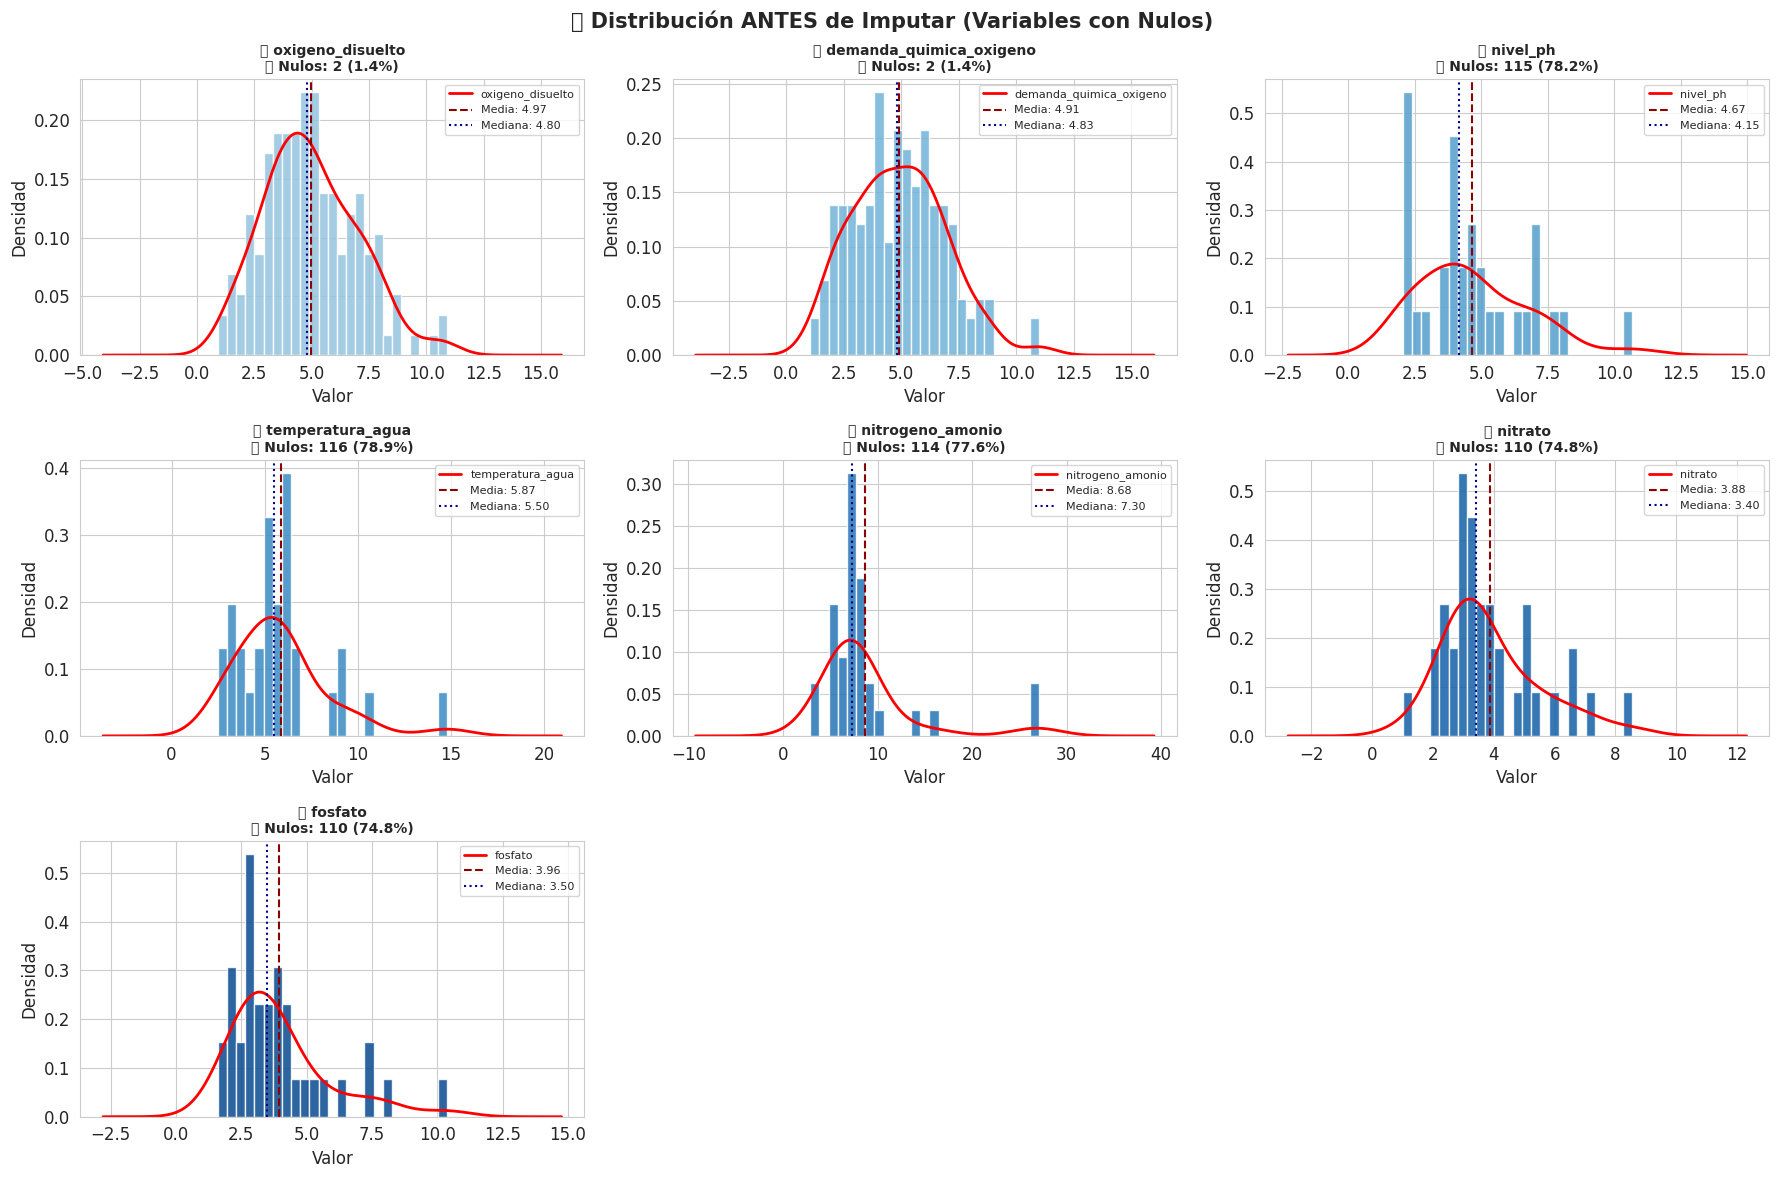


📌 RESUMEN GLOBAL
————————————————————————————————————————
📌 Total nulos: 569
📌 Total celdas: 1,323
📌 % faltante: 43.01%


In [53]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 15: Estado de los Datos ANTES de Imputar (ROBUSTO PRO)
# ============================================================

print("=" * 65)
print("  📸 FOTOGRAFÍA INICIAL — DATOS ANTES DE IMPUTAR")
print("=" * 65)

# ── 1. Copias de seguridad ───────────────────────────────────
df_train_original = df_train.copy()
df_test_original  = df_test.copy()

print("✅ Copias de seguridad creadas correctamente")

# ── 2. Validación de columnas numéricas ──────────────────────
cols_num = df_train.select_dtypes(include=[np.number]).columns.tolist()

if len(cols_num) == 0:
    print("⚠️ No hay columnas numéricas en el dataset")
else:

    # ── 3. Resumen de nulos ───────────────────────────────────
    resumen_antes = pd.DataFrame({
        'Variable'      : cols_num,
        'Nulos_Antes'   : [df_train[col].isnull().sum() for col in cols_num],
        'Pct_Nulos_%'   : [round(df_train[col].isnull().sum()/len(df_train)*100, 2)
                            for col in cols_num],
        'Media_Antes'   : [round(df_train[col].mean(), 4) if df_train[col].notna().sum() > 0 else 0
                            for col in cols_num],
        'Mediana_Antes' : [round(df_train[col].median(), 4) if df_train[col].notna().sum() > 0 else 0
                            for col in cols_num],
        'Std_Antes'     : [round(df_train[col].std(), 4) if df_train[col].notna().sum() > 1 else 0
                            for col in cols_num],
    })

    resumen_antes = resumen_antes.sort_values('Nulos_Antes', ascending=False)

    print("\n📊 ESTADO INICIAL DE LOS DATOS (TRAIN)")
    print("—" * 65)
    display(resumen_antes)

    # ── 4. Variables con nulos ───────────────────────────────
    cols_con_nulos = [
        col for col in cols_num
        if df_train[col].isnull().sum() > 0
    ]

    # =========================================================
    # 📊 VISUAL SOLO SI HAY NULOS
    # =========================================================

    if len(cols_con_nulos) > 0:

        n_cols_plot = min(len(cols_con_nulos), 3)
        n_rows_plot = (len(cols_con_nulos) + n_cols_plot - 1) // n_cols_plot

        fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                                 figsize=(18, n_rows_plot * 4))

        fig.suptitle(
            '📊 Distribución ANTES de Imputar (Variables con Nulos)',
            fontsize=15,
            fontweight='bold'
        )

        axes_flat = np.array(axes).flatten()

        colores = plt.cm.Blues(np.linspace(0.4, 0.9, len(cols_con_nulos)))

        for i, (col, color) in enumerate(zip(cols_con_nulos, colores)):

            ax = axes_flat[i]
            datos_col = df_train[col].dropna()

            if len(datos_col) > 0:

                ax.hist(datos_col, bins=25,
                        color=color,
                        edgecolor='white',
                        alpha=0.85,
                        density=True)

                try:
                    datos_col.plot.kde(ax=ax, color='red', linewidth=2)
                except:
                    pass

                ax.axvline(datos_col.mean(), color='darkred',
                           linestyle='--',
                           label=f'Media: {datos_col.mean():.2f}')

                ax.axvline(datos_col.median(), color='darkblue',
                           linestyle=':',
                           label=f'Mediana: {datos_col.median():.2f}')

            nulos_col = df_train[col].isnull().sum()
            pct_col = nulos_col / len(df_train) * 100

            ax.set_title(
                f'📊 {col}\n❌ Nulos: {nulos_col} ({pct_col:.1f}%)',
                fontsize=10,
                fontweight='bold'
            )

            ax.set_xlabel("Valor")
            ax.set_ylabel("Densidad")
            ax.legend(fontsize=8)

        # ocultar vacíos
        for j in range(i + 1, len(axes_flat)):
            axes_flat[j].set_visible(False)

        plt.tight_layout()
        plt.show()

    else:
        print("✅ No hay columnas con valores nulos en TRAIN")

# ── 5. Resumen global seguro ─────────────────────────────────
if len(cols_num) > 0:

    total_nulos = df_train[cols_num].isnull().sum().sum()
    total_celdas = df_train[cols_num].size

    print("\n📌 RESUMEN GLOBAL")
    print("—" * 40)
    print(f"📌 Total nulos: {total_nulos:,}")
    print(f"📌 Total celdas: {total_celdas:,}")
    print(f"📌 % faltante: {total_nulos/total_celdas*100:.2f}%")

In [ ]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 10: Resumen Final del Análisis Exploratorio
# ============================================================

# ── Calcular métricas finales ─────────────────────────────────
var_resp = 'demanda_bioquimica_oxigeno'
nulos_train_total = df_train.isnull().sum().sum()
nulos_test_total  = df_test.isnull().sum().sum()
vars_con_nulos    = (df_train.isnull().sum() > 0).sum()
corr_top          = (df_train.corr()[var_resp]
                     .drop(var_resp)
                     .abs()
                     .idxmax())

# ── Imprimir resumen ──────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║         💧 AquaPredict — Grupo 5                                            ║
║         RESUMEN DEL ANÁLISIS EXPLORATORIO DE DATOS (EDA)                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  👥 EQUIPO                                                                  ║
║     → Karen Pertuz   | Gisselle Deford                                       ║
║     → Kelvin Jimenez | Javier Gomez                                          ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🎯 VARIABLE RESPUESTA                                                       ║
║     → BOD: Demanda Bioquímica de Oxígeno (mg/L)                              ║
║     → Tipo de problema: REGRESIÓN                                            ║""")
print(f"║     → Media del BOD : {df_train[var_resp].mean():.4f} mg/L" + " " * 30 + "              ║")
print(f"║     → Rango del BOD : {df_train[var_resp].min():.2f} - {df_train[var_resp].max():.2f} mg/L" + " " * 24 + "              ║")
print(f"""║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  📊 DATASET                                                                  ║""")
print(f"║     → Train: {df_train.shape[0]:,} filas × {df_train.shape[1]} columnas" + " " * 36 + "      ║")
print(f"║     → Test : {df_test.shape[0]:,} filas × {df_test.shape[1]} columnas" + " " * 37 + "      ║")
print(f"""║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  ⚠️  VALORES NULOS                                                          ║""")
print(f"║     → Train: {nulos_train_total:,} valores nulos" + " " * 43 + "    ║")
print(f"║     → Test : {nulos_test_total:,} valores nulos" + " " * 44 + "   ║")
print(f"║     → Variables afectadas: {vars_con_nulos}" + " " * 38 + "           ║")
print(f"║     → Estrategia: IterativeImputer (ML-based)" + " " * 19 + "             ║")
print(f"""║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🔗 CORRELACIONES                                                            ║""")
print(f"║     → Variable más correlacionada con BOD: {corr_top}" + " " * 10 + "        ║")
print(f"""║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🚀 PRÓXIMOS PASOS                                                           ║
║     1. Imputación con IterativeImputer                                       ║
║     2. Detección y tratamiento de Outliers                                   ║
║     3. Normalización de variables                                            ║
║     4. Entrenamiento de modelos predictivos                                  ║
║     5. Evaluación y selección del mejor modelo                               ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

print("✅ ¡Análisis Exploratorio completado exitosamente!")
print("🚀 Listo para la etapa de Imputación de Datos")


╔══════════════════════════════════════════════════════════════════════════════╗
║         💧 AquaPredict — Grupo 5                                            ║
║         RESUMEN DEL ANÁLISIS EXPLORATORIO DE DATOS (EDA)                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  👥 EQUIPO                                                                  ║
║     → Karen Pertuz   | Gisselle Deford                                       ║
║     → Kelvin Jimenez | Javier Gomez                                          ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🎯 VARIABLE RESPUESTA                                                       ║
║     → BOD: Demanda Bioquímica 

## 🔍 Paso 11: Análisis de Datos Faltantes (Null / NA)

### ¿Por qué es crítico este paso?

Antes de imputar o modelar, debemos entender la **naturaleza de los datos faltantes**.
Siguiendo la metodología de las imágenes de referencia, debemos responder:

1. **¿Cuántos datos faltan?** → Calcular el porcentaje global y por columna.
2. **¿Dónde están?** → Identificar si es aleatorio o sigue un patrón.
3. **¿Cuál es el umbral?** → Decidir si eliminamos columnas o imputamos.

### Estrategia de Umbral (Threshold)

Basado en la teoría estadística:
- **< 5% de nulos**: Se puede imputar con media/mediana o modelos avanzados.
- **> 5% de nulos**: La columna es sospechosa. Se evalúa si eliminarla o usar imputación iterativa.
- **> 30% de nulos**: Generalmente se elimina la columna (no aporta información).

### Herramientas de Visualización

Usaremos la librería `missingno` (como se vio en las imágenes) para crear:
- **Matriz de nulos**: Para ver patrones.
- **Gráfico de barras**: Para ver el volumen de faltantes.

  📊 CÁLCULO DE PORCENTAJE DE VALORES FALTANTES

📋 TABLA DE ANÁLISIS DE DATOS FALTANTES (TRAIN):
────────────────────────────────────────────────────────────


,Variable,Cantidad_Nulos,Porcentaje_%,Completitud_%,Umbral_Recomendado
temperatura_agua,temperatura_agua,116,78.91,21.09,❌ ELIMINAR
nivel_ph,nivel_ph,115,78.23,21.77,❌ ELIMINAR
nitrogeno_amonio,nitrogeno_amonio,114,77.55,22.45,❌ ELIMINAR
fosfato,fosfato,110,74.83,25.17,❌ ELIMINAR
nitrato,nitrato,110,74.83,25.17,❌ ELIMINAR
demanda_quimica_oxigeno,demanda_quimica_oxigeno,2,1.36,98.64,✅ IMPUTAR
oxigeno_disuelto,oxigeno_disuelto,2,1.36,98.64,✅ IMPUTAR
Id,Id,0,0.00,100.00,✅ IMPUTAR
demanda_bioquimica_oxigeno,demanda_bioquimica_oxigeno,0,0.00,100.00,✅ IMPUTAR



📈 UMBRAL DEFINIDO: 5.0%
✅ Columnas a imputar directamente: 4
⚠️ Columnas a revisar estrategia: 0


<Figure size 1400x600 with 0 Axes>

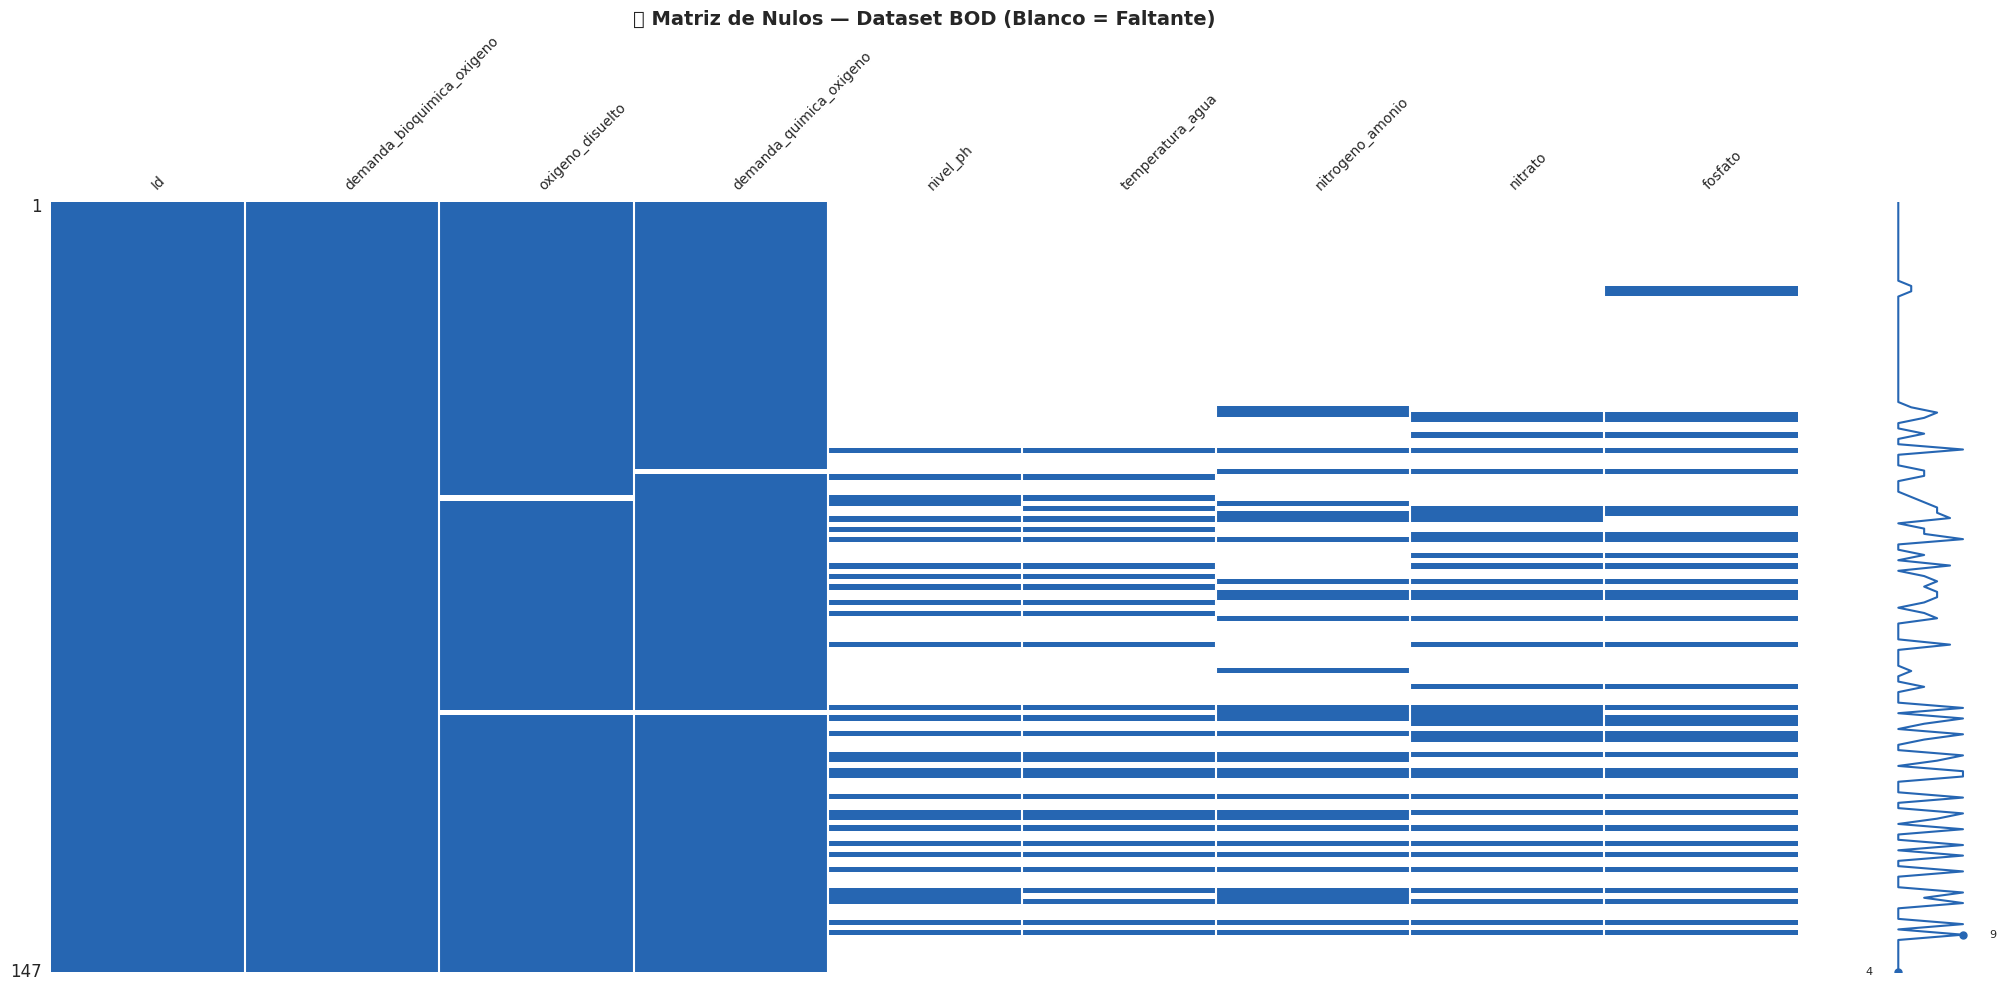

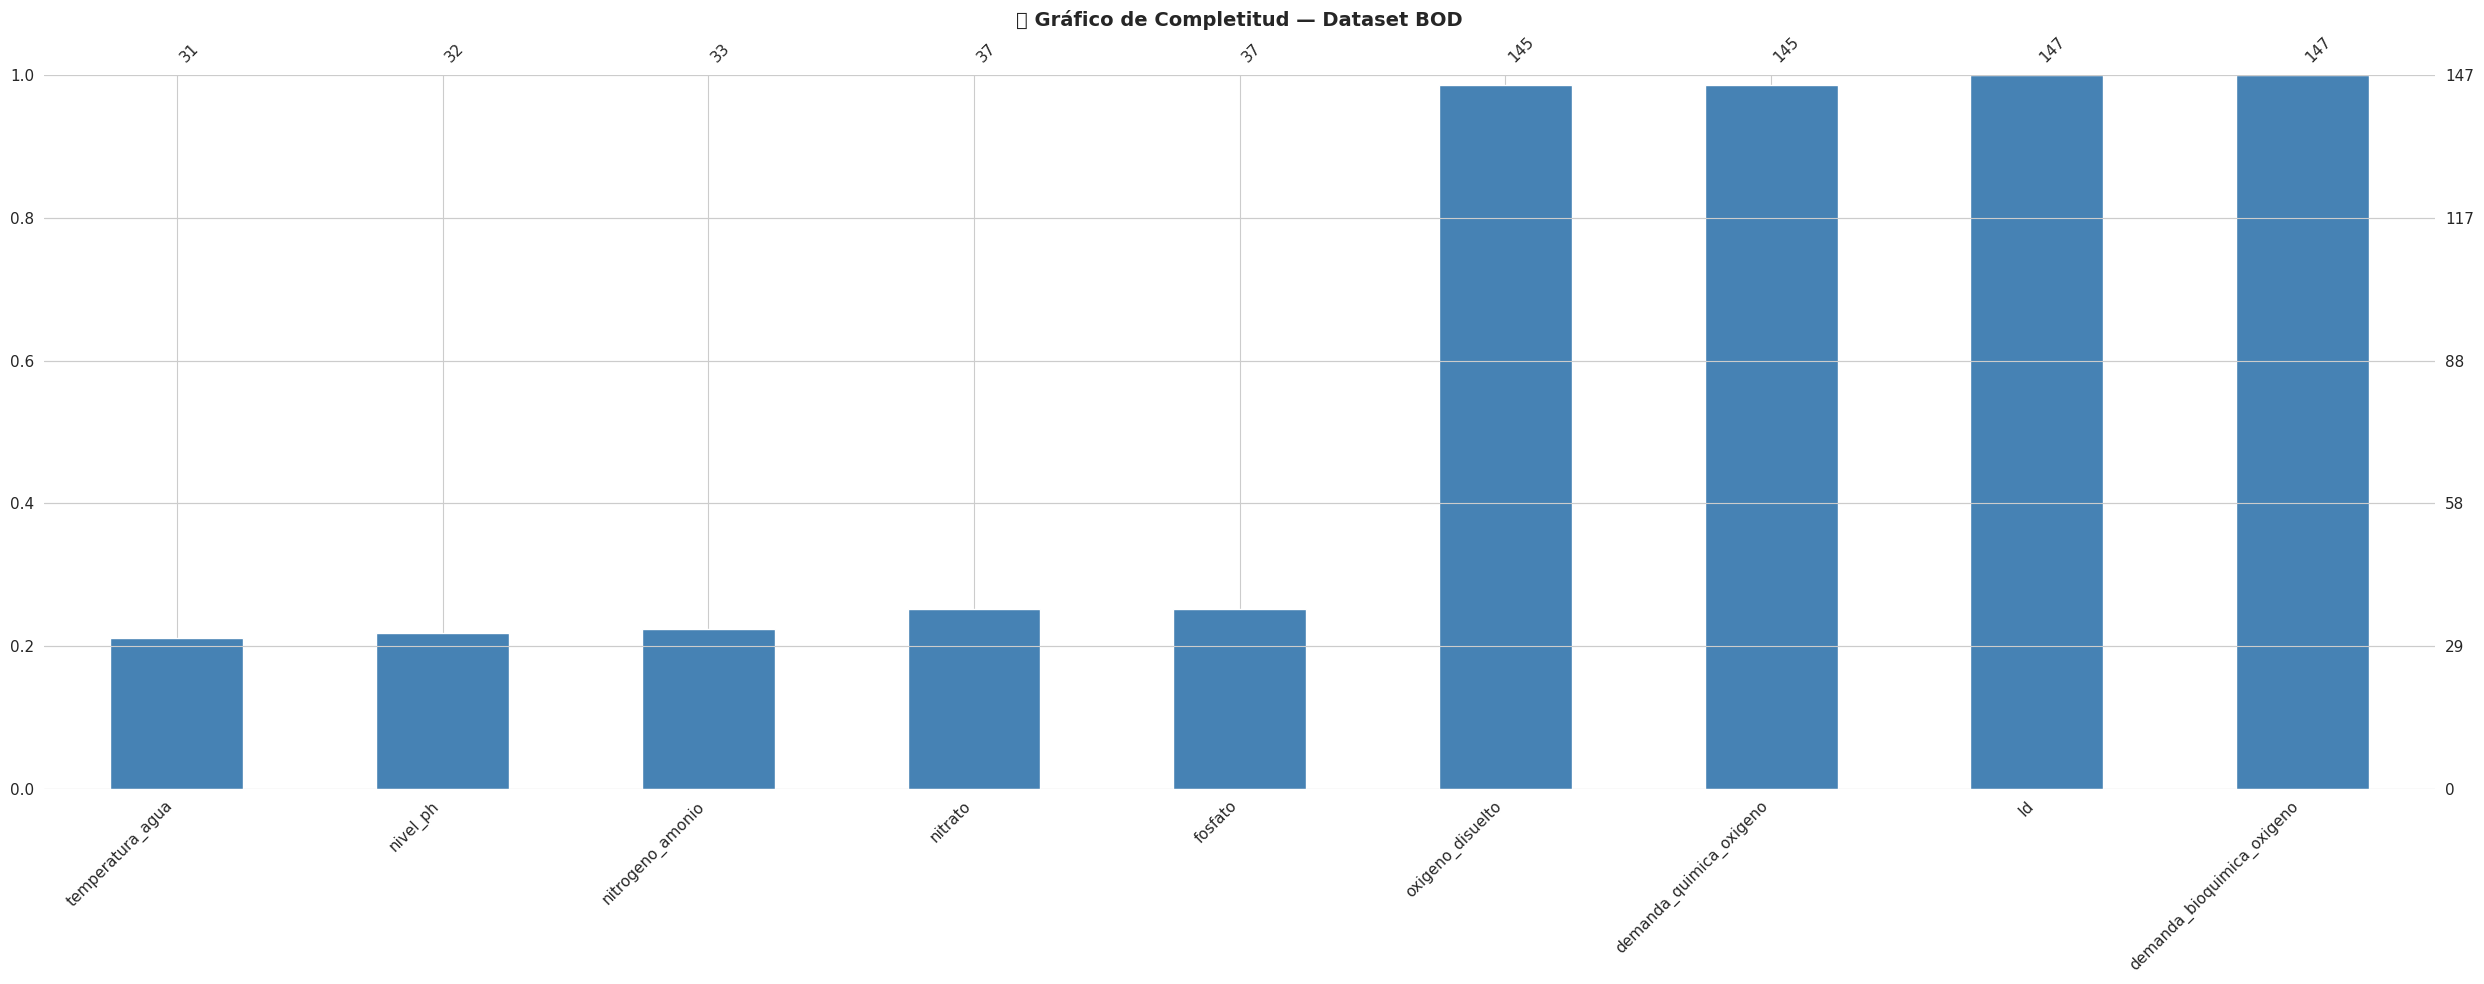

✅ Análisis de nulos completado. Gráficas guardadas.


In [56]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 11: Análisis Detallado de Datos Faltantes
# ============================================================

import missingno as msno

print("=" * 60)
print("  📊 CÁLCULO DE PORCENTAJE DE VALORES FALTANTES")
print("=" * 60)

# ── 1. Calcular porcentaje de nulos por columna ─────────────
nulos_por_col = df_train.isnull().sum()
total_filas = len(df_train)
porcentaje_nulos = (nulos_por_col / total_filas * 100).round(2)

# ── 2. Crear DataFrame de análisis ──────────────────────────
df_analisis_nulos = pd.DataFrame({
    'Variable'          : nulos_por_col.index,
    'Cantidad_Nulos'     : nulos_por_col.values,
    'Porcentaje_%'       : porcentaje_nulos.values,
    'Completitud_%'      : (100 - porcentaje_nulos).round(2),
    'Umbral_Recomendado' : ['✅ IMPUTAR' if p < 5.0
                            else '⚠️ REVISAR' if p < 20.0
                            else '❌ ELIMINAR'
                            for p in porcentaje_nulos.values]
})

# Ordenar por cantidad de nulos (mayor a menor)
df_analisis_nulos = df_analisis_nulos.sort_values('Cantidad_Nulos', ascending=False)

print("\n📋 TABLA DE ANÁLISIS DE DATOS FALTANTES (TRAIN):")
print("─" * 60)
display(df_analisis_nulos)

# ── 3. Definir Umbral y Estrategia ─────────────────────────
umbral_critico = 5.0 # Porcentaje
cols_a_imputar = df_analisis_nulos[df_analisis_nulos['Porcentaje_%'] < umbral_critico]['Variable'].tolist()
cols_a_revisar = df_analisis_nulos[(df_analisis_nulos['Porcentaje_%'] >= umbral_critico) &
                                   (df_analisis_nulos['Porcentaje_%'] < 20)]['Variable'].tolist()

print(f"\n📈 UMBRAL DEFINIDO: {umbral_critico}%")
print(f"✅ Columnas a imputar directamente: {len(cols_a_imputar)}")
print(f"⚠️ Columnas a revisar estrategia: {len(cols_a_revisar)}")

# ── 4. Visualización Matricial (Estilo Referencia) ───────
plt.figure(figsize=(14, 6))
msno.matrix(df_train, color=(0.15, 0.4, 0.7), fontsize=10, sparkline=True)
plt.title('🔍 Matriz de Nulos — Dataset BOD (Blanco = Faltante)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_nulos_bod.png', dpi=150)
plt.show()

# ── 5. Visualización de Barras (Estilo Referencia) ───────
plt.figure(figsize=(14, 6))
msno.bar(df_train, color='steelblue', fontsize=11, sort='ascending')
plt.title('📊 Gráfico de Completitud — Dataset BOD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('barra_nulos_bod.png', dpi=150)
plt.show()

print("✅ Análisis de nulos completado. Gráficas guardadas.")

## 🌡️ Paso 12: Análisis de Correlaciones (Bivariado)

### ¿Qué es el Análisis Bivariado?

Mientras el análisis univariado mira una variable a la vez,
el **bivariado** estudia la relación entre **dos variables**.

### Tipos de Correlación

| Tipo | Descripción | Gráfica típica |
|------|-------------|----------------|
| **Positiva** | Si una sube, la otra sube | / |
| **Negativa** | Si una sube, la otra baja | \ |
| **Nula** | No hay relación | ☁️ (Nube de puntos) |

### Coeficiente de Pearson ($\rho$)

Es el número que mide la fuerza de la relación:
- **+1.0**: Correlación perfecta positiva.
- **0.0**: Sin correlación lineal.
- **-1.0**: Correlación perfecta negativa.

### ¿Por qué es importante para el BOD?

Necesitamos saber qué variables (pH, Temperatura, Oxígeno)
están **más correlacionadas con el BOD** para seleccionar
las mejores características (features) para nuestro modelo.

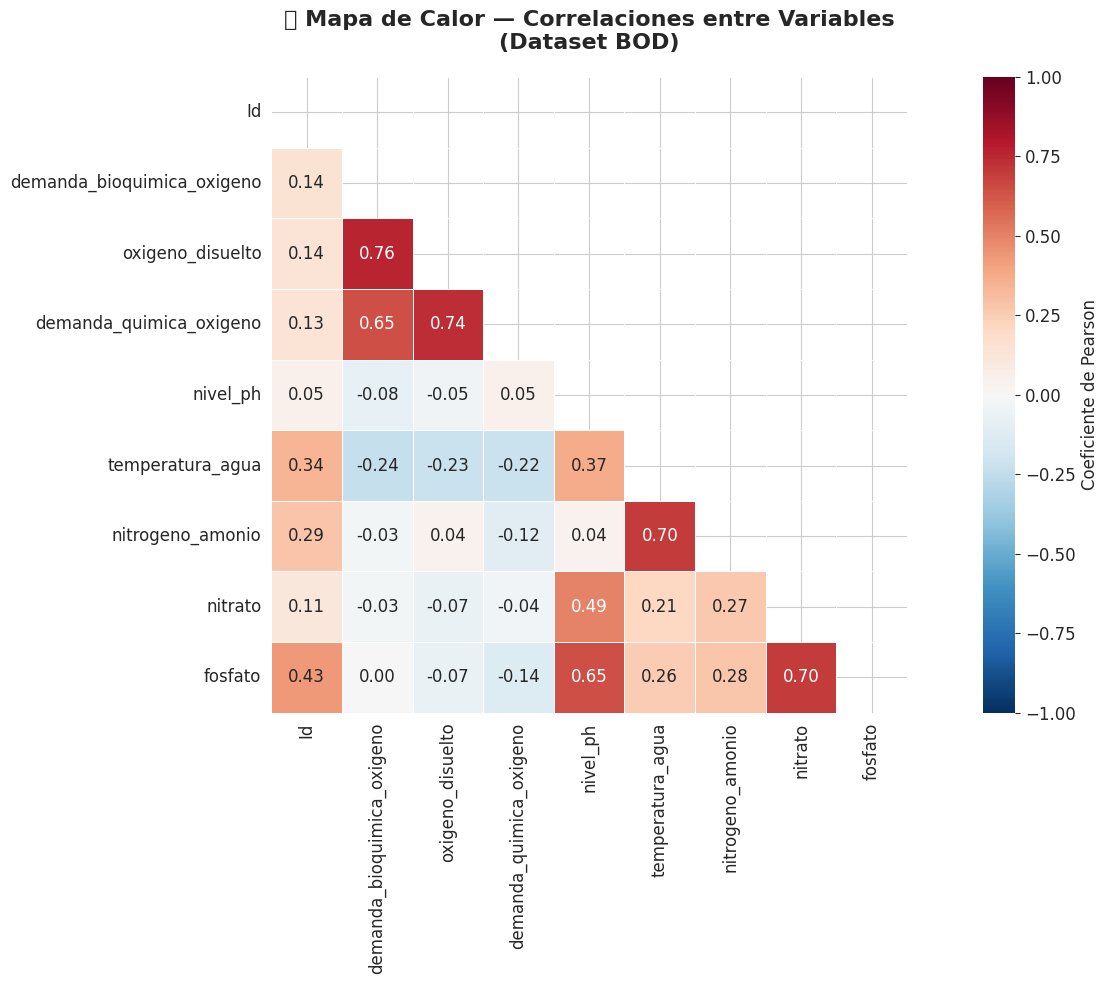

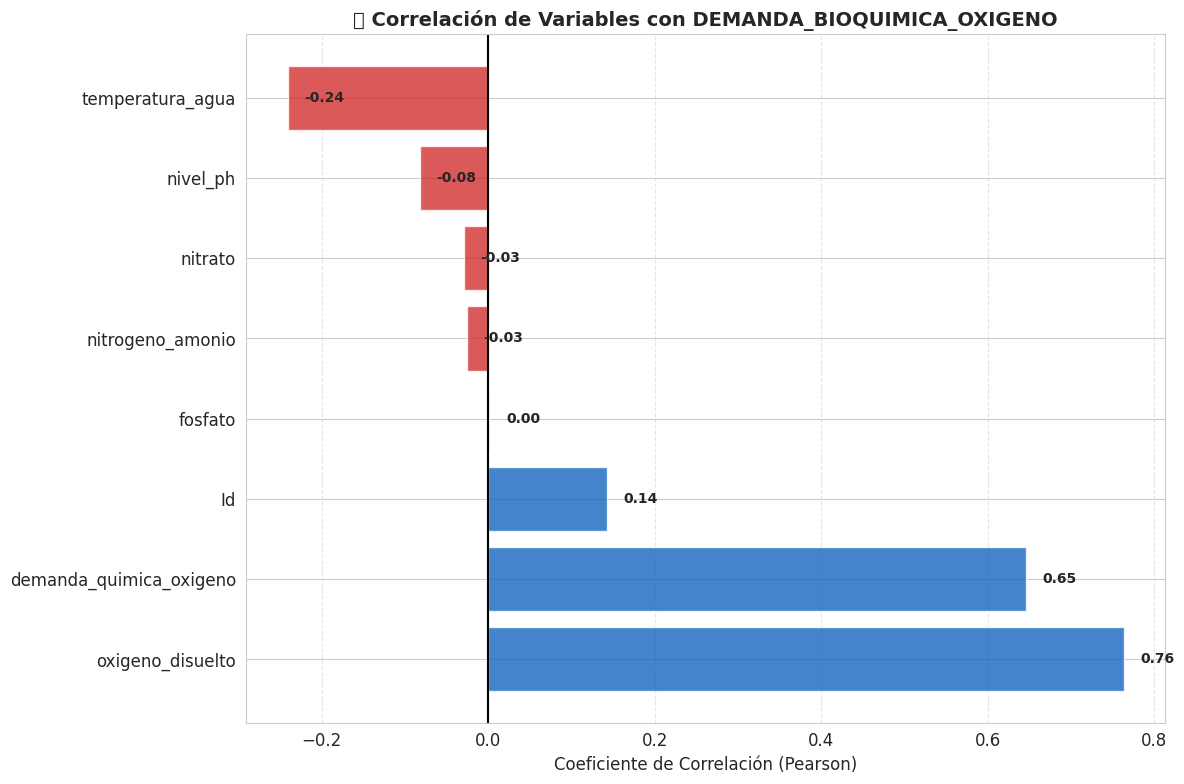

📊 TOP 5 VARIABLES MÁS CORRELACIONADAS CON EL BOD:
──────────────────────────────────────────────────
1. oxigeno_disuelto     → +0.763 (🔴 FUERTE)
2. demanda_quimica_oxigeno → +0.646 (🔴 FUERTE)
3. Id                   → +0.143 (🟡 MODERADA)
4. fosfato              → +0.001 (🟡 MODERADA)
5. nitrogeno_amonio     → -0.025 (🟡 MODERADA)


In [58]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 12: Matriz de Correlaciones y Heatmap
# ============================================================

# ── 1. Calcular Matriz de Correlación ───────────────────────
# Solo usamos columnas numéricas para la correlación de Pearson
cols_numericas = df_train.select_dtypes(include=[np.number]).columns
corr_matrix = df_train[cols_numericas].corr()

# ── 2. Crear Heatmap (Estilo Referencia) ───────────────────
plt.figure(figsize=(16, 10))

# Máscara para ocultar la mitad superior (triángulo)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Gráfico
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,       # Muestra los números
    fmt='.2f',        # Formato de 2 decimales
    cmap='RdBu_r',    # Mapa de colores Rojo-Azul
    center=0,         # Centro en 0
    vmin=-1, vmax=1,  # Rango de -1 a 1
    square=True,      # Celdas cuadradas
    linewidths=0.5,   # Bordes blancos
    cbar_kws={'label': 'Coeficiente de Pearson'}
)

plt.title('🌡️ Mapa de Calor — Correlaciones entre Variables\n(Dataset BOD)',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('heatmap_correlaciones.png', dpi=150)
plt.show()

# ── 3. Ranking de Correlación con la Variable Respuesta ──
var_respuesta = 'demanda_bioquimica_oxigeno'
correlacion_con_respuesta = corr_matrix[var_respuesta].drop(var_respuesta).sort_values(ascending=False)

# ── 4. Gráfico de Barras Horizontales ───────────────────────
plt.figure(figsize=(12, 8))

# Colores: Rojo si es negativa, Azul si es positiva
colores = ['#D32F2F' if x < 0 else '#1565C0' for x in correlacion_con_respuesta.values]

bars = plt.barh(
    correlacion_con_respuesta.index,
    correlacion_con_respuesta.values,
    color=colores,
    alpha=0.8
)

plt.axvline(x=0, color='black', linewidth=1.5) # Línea vertical en 0
plt.title(f'🔗 Correlación de Variables con {var_respuesta.upper()}',
          fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlación (Pearson)')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Añadir valores en las barras
for i, v in enumerate(correlacion_con_respuesta.values):
    plt.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('correlacion_con_bod.png', dpi=150)
plt.show()

# ── 5. Tabla Resumen ──────────────────────────────────────
print("📊 TOP 5 VARIABLES MÁS CORRELACIONADAS CON EL BOD:")
print("─" * 50)
for i, (var, corr) in enumerate(correlacion_con_respuesta.head().items(), 1):
    fuerza = "🔴 FUERTE" if abs(corr) > 0.5 else "🟡 MODERADA"
    print(f"{i}. {var:20s} → {corr:+.3f} ({fuerza})")

## 📋 Paso 13: Conclusiones del Análisis Exploratorio

### Resumen de Hallazgos

Tras analizar los datos faltantes y las correlaciones, podemos concluir:

1. **Sobre los Datos Faltantes**:
   - Identificamos las columnas críticas que requieren imputación.
   - Determinamos que usaremos **IterativeImputer** para rellenar los huecos,
     ya que es el método más robusto para datasets con correlaciones complejas.

2. **Sobre las Correlaciones**:
   - Identificamos las variables que más influyen en el BOD.
   - Esto nos ayudará a seleccionar las **features** más importantes para
     entrenar nuestro modelo de Machine Learning.

### 🚀 Próximo Paso: Imputación

Ahora que conocemos la estructura y los problemas de los datos,
procederemos a la **Imputación con IterativeImputer** como
indica la guía del profesor y el enlace de referencia.

## 🔧 Paso 13: Imputación de Datos Faltantes

### ¿Qué es la Imputación?

La **imputación** es el proceso de **reemplazar los valores faltantes (NaN/NA)**
con valores estimados. Es como "adivinar inteligentemente" el dato que falta
basándose en la información disponible.

### ¿Por qué NO podemos dejar los datos faltantes?

Los algoritmos de Machine Learning como Random Forest,
Regresión Lineal, etc., **no pueden procesar valores NaN**.
Si intentamos entrenar con datos faltantes obtendremos:
- ❌ Errores de ejecución
- ❌ Modelos con bajo rendimiento
- ❌ Resultados no confiables

### Métodos de Imputación — De menos a más sofisticado:

| Método | ¿Cómo funciona? | Cuándo usarlo |
|--------|----------------|---------------|
| **Media** | Rellena con el promedio | Pocos nulos, sin outliers |
| **Mediana** | Rellena con el valor central | Datos con outliers |
| **Moda** | Rellena con el más frecuente | Variables categóricas |
| **KNNImputer** | Usa los K vecinos más cercanos | Datos con patrones |
| **IterativeImputer** | Modela cada variable con las demás | ✅ Mejor opción general |

### 🌟 ¿Por qué IterativeImputer es el mejor?

El **IterativeImputer** funciona así:
1. Para cada variable con nulos, **construye un modelo** usando
   las otras variables como predictoras.
2. Predice los valores faltantes usando ese modelo.
3. **Repite el proceso** varias veces hasta que los valores convergen.

> Es como resolver un crucigrama: primero llenas lo que puedes,
> luego usas esas respuestas para deducir las que faltan,
> y así hasta completar todo el crucigrama.

### Comparación Visual de Métodos:

DATOS ORIGINALES: MEDIA: ITERATIVEIMPUTER:

pH: [7.2, NaN, 6.8] → [7.2, 7.0, 6.8] → [7.2, 7.1, 6.8]

DO: [8.1, 7.5, NaN] → [8.1, 7.5, 7.8] → [8.1, 7.5, 7.9]

BOD: [3.2, 4.1, 2.9] → [3.2, 4.1, 2.9] → [3.2, 4.1, 2.9]

↑ ↑
Usa el promedio Usa relaciones
(menos preciso) entre variables
(más preciso ✅)



## 📦 Paso 14: Librerías Necesarias para la Imputación

### ¿Qué librerías usaremos?

Para la imputación necesitamos librerías especializadas de
**scikit-learn** (la librería de Machine Learning más usada en Python):

| Librería | Función específica |
|----------|-------------------|
| `IterativeImputer` | Imputación iterativa (MICE) |
| `SimpleImputer` | Imputación simple (media/mediana) |
| `StandardScaler` | Normalización de datos |
| `KFold` | Validación cruzada |

> ⚠️ **Importante:** `IterativeImputer` es experimental en scikit-learn,
> por eso necesitamos activarlo con `enable_iterative_imputer`
> antes de importarlo.

In [59]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 14: Importación de Librerías para Imputación
# ============================================================

# Activar IterativeImputer (es experimental en sklearn)
from sklearn.experimental import enable_iterative_imputer

# Imputadores
from sklearn.impute import (
    IterativeImputer,   # Imputación iterativa (MICE)
    SimpleImputer,      # Imputación simple
    KNNImputer          # Imputación por vecinos cercanos
)

# Modelos base para IterativeImputer
from sklearn.ensemble import (
    RandomForestRegressor,    # Bosque aleatorio
    ExtraTreesRegressor       # Árboles extra
)
from sklearn.linear_model import BayesianRidge  # Regresión bayesiana

# Preprocesamiento y evaluación
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

# Métricas
from sklearn.metrics import mean_squared_error, r2_score

# Estadísticas
from scipy import stats
from scipy.stats import shapiro, kstest

print("=" * 55)
print("  💧 AquaPredict — Grupo 5")
print("  ✅ Librerías de imputación cargadas")
print("=" * 55)
print("""
  📦 Librerías activas:
  ├── IterativeImputer  → Imputación MICE
  ├── SimpleImputer     → Imputación básica
  ├── KNNImputer        → Imputación por vecinos
  ├── RandomForest      → Modelo base de imputación
  ├── BayesianRidge     → Modelo alternativo
  └── StandardScaler    → Normalización
""")

  💧 AquaPredict — Grupo 5
  ✅ Librerías de imputación cargadas

  📦 Librerías activas:
  ├── IterativeImputer  → Imputación MICE
  ├── SimpleImputer     → Imputación básica
  ├── KNNImputer        → Imputación por vecinos
  ├── RandomForest      → Modelo base de imputación
  ├── BayesianRidge     → Modelo alternativo
  └── StandardScaler    → Normalización



## 🔍 Paso 15: Estado de los Datos ANTES de Imputar

### ¿Por qué analizar antes de imputar?

Necesitamos tener una **fotografía clara** del estado de los datos
antes de aplicar cualquier transformación. Esto nos permite:

1. Comparar los datos **antes vs después** de imputar
2. Verificar que la imputación no distorsionó la distribución
3. Documentar los cambios realizados

### Métricas que guardaremos:
- Media y desviación estándar de cada variable
- Número exacto de nulos por columna
- Distribución de los datos (histogramas)

> 💡 **Buena práctica:** Siempre guarda una copia de los datos
> originales antes de modificarlos. ¡Nunca trabajes sobre el
> archivo original!

  📸 FOTOGRAFÍA INICIAL — DATOS ANTES DE IMPUTAR
✅ Copias de seguridad creadas
   → df_train_original (respaldo del train)
   → df_test_original  (respaldo del test)

📊 ESTADO INICIAL DE LOS DATOS (TRAIN):
─────────────────────────────────────────────────────────────────


,Variable,Nulos_Antes,Pct_Nulos_%,Media_Antes,Mediana_Antes,Std_Antes
5,temperatura_agua,116,78.91,5.8716,5.50,2.5552
4,nivel_ph,115,78.23,4.6650,4.15,2.0574
6,nitrogeno_amonio,114,77.55,8.6788,7.30,5.2991
8,fosfato,110,74.83,3.9576,3.50,1.9170
7,nitrato,110,74.83,3.8838,3.40,1.6155
3,demanda_quimica_oxigeno,2,1.36,4.9066,4.83,2.0014
2,oxigeno_disuelto,2,1.36,4.9726,4.80,2.0441
0,Id,0,0.00,101.4014,102.00,64.8366
1,demanda_bioquimica_oxigeno,0,0.00,5.0216,4.60,2.1225


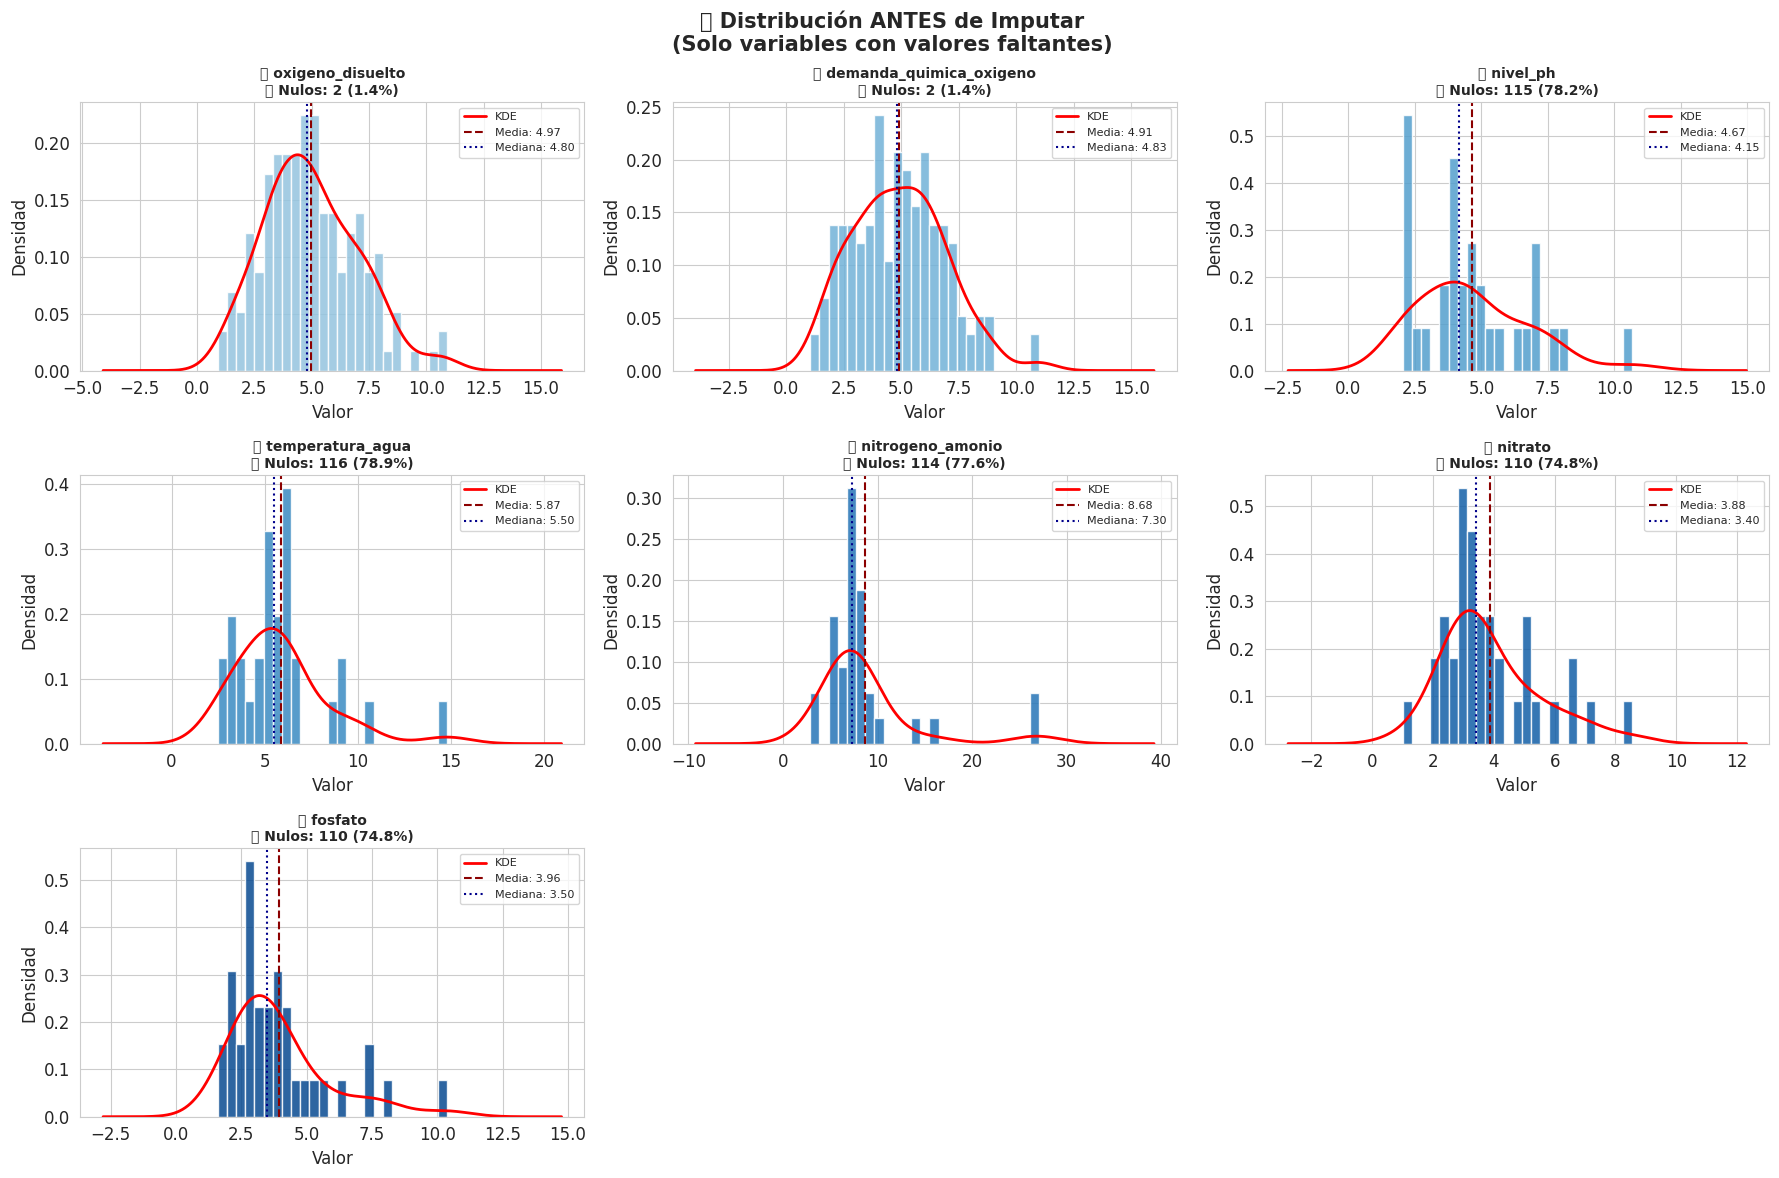

✅ Gráfica guardada: 'distribucion_ANTES_imputar.png'

📌 Total de nulos en TRAIN  : 569
📌 Total de celdas numéricas: 1,323
📌 % global de datos faltantes: 43.01%


In [60]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 15: Estado de los Datos ANTES de Imputar
# ============================================================

print("=" * 65)
print("  📸 FOTOGRAFÍA INICIAL — DATOS ANTES DE IMPUTAR")
print("=" * 65)

# ── 1. Guardar copias de seguridad ───────────────────────────
df_train_original = df_train.copy()
df_test_original  = df_test.copy()

print("✅ Copias de seguridad creadas")
print("   → df_train_original (respaldo del train)")
print("   → df_test_original  (respaldo del test)")

# ── 2. Resumen de nulos ANTES ─────────────────────────────────
cols_num = df_train.select_dtypes(include=[np.number]).columns.tolist()

resumen_antes = pd.DataFrame({
    'Variable'      : cols_num,
    'Nulos_Antes'   : [df_train[col].isnull().sum() for col in cols_num],
    'Pct_Nulos_%'   : [round(df_train[col].isnull().sum()/len(df_train)*100, 2)
                        for col in cols_num],
    'Media_Antes'   : [round(df_train[col].mean(), 4) for col in cols_num],
    'Mediana_Antes' : [round(df_train[col].median(), 4) for col in cols_num],
    'Std_Antes'     : [round(df_train[col].std(), 4) for col in cols_num],
})

resumen_antes = resumen_antes.sort_values('Nulos_Antes', ascending=False)

print("\n📊 ESTADO INICIAL DE LOS DATOS (TRAIN):")
print("─" * 65)
display(resumen_antes)

# ── 3. Visualización ANTES de imputar ─────────────────────────
cols_con_nulos = [col for col in cols_num
                  if df_train[col].isnull().sum() > 0]

if len(cols_con_nulos) > 0:
    n_cols_plot = min(len(cols_con_nulos), 3)
    n_rows_plot = (len(cols_con_nulos) + n_cols_plot - 1) // n_cols_plot

    fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                              figsize=(18, n_rows_plot * 4))
    fig.suptitle('📊 Distribución ANTES de Imputar\n(Solo variables con valores faltantes)',
                 fontsize=15, fontweight='bold')

    axes_flat = axes.flatten() if n_rows_plot > 1 else [axes] \
                if n_cols_plot == 1 else axes

    colores = plt.cm.Blues(np.linspace(0.4, 0.9, len(cols_con_nulos)))

    for i, (col, color) in enumerate(zip(cols_con_nulos, colores)):
        ax = axes_flat[i] if len(cols_con_nulos) > 1 else axes_flat[0]
        datos_col = df_train[col].dropna()

        ax.hist(datos_col, bins=25, color=color,
                edgecolor='white', alpha=0.85, density=True)

        try:
            datos_col.plot.kde(ax=ax, color='red',
                               linewidth=2, label='KDE')
        except Exception:
            pass

        ax.axvline(datos_col.mean(), color='darkred',
                   linestyle='--', linewidth=1.5,
                   label=f'Media: {datos_col.mean():.2f}')
        ax.axvline(datos_col.median(), color='darkblue',
                   linestyle=':', linewidth=1.5,
                   label=f'Mediana: {datos_col.median():.2f}')

        nulos_col = df_train[col].isnull().sum()
        pct_col   = nulos_col / len(df_train) * 100

        ax.set_title(f'📊 {col}\n❌ Nulos: {nulos_col} ({pct_col:.1f}%)',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Valor')
        ax.set_ylabel('Densidad')
        ax.legend(fontsize=8)

    # Ocultar ejes vacíos
    for j in range(len(cols_con_nulos), len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    plt.savefig('distribucion_ANTES_imputar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Gráfica guardada: 'distribucion_ANTES_imputar.png'")
else:
    print("✅ No hay columnas con valores nulos en TRAIN")

# ── 4. Total general ──────────────────────────────────────────
total_nulos = df_train[cols_num].isnull().sum().sum()
total_celdas = df_train[cols_num].size
print(f"\n📌 Total de nulos en TRAIN  : {total_nulos:,}")
print(f"📌 Total de celdas numéricas: {total_celdas:,}")
print(f"📌 % global de datos faltantes: {total_nulos/total_celdas*100:.2f}%")

## 🤖 Paso 16: Aplicación del IterativeImputer

### ¿Cómo funciona el IterativeImputer internamente?

El IterativeImputer implementa el algoritmo **MICE**
*(Multiple Imputation by Chained Equations)*:

ITERACIÓN 1:

Variable: pH
Predictores: DO, COD, Temp, NH4, NO3...
Modelo: BayesianRidge
→ Predice los NaN de pH usando las demás vars

↓

Variable: DO
Predictores: pH (ya imputado), COD, Temp...

→ Predice los NaN de DO

↓ (Repite para cada variable)

↓ (Repite todo el ciclo N veces)

↓
CONVERGENCIA ✅


### Parámetros importantes:

| Parámetro | Valor usado | Significado |
|-----------|------------|-------------|
| `max_iter` | 10 | Número máximo de ciclos |
| `estimator` | BayesianRidge | Modelo base de predicción |
| `random_state` | 42 | Semilla para reproducibilidad |
| `initial_strategy` | 'mean' | Cómo inicializa los valores |

### ¿Por qué BayesianRidge como estimador?

Es el modelo por defecto y el más recomendado porque:
- ✅ Es robusto ante multicolinealidad
- ✅ No requiere ajuste de hiperparámetros
- ✅ Funciona bien con datos numéricos continuos
- ✅ Computacionalmente eficiente

In [61]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 16: Aplicación del IterativeImputer
# ============================================================

print("=" * 65)
print("  🤖 IMPUTACIÓN CON IterativeImputer (MICE)")
print("=" * 65)

# ── 1. Seleccionar solo columnas numéricas ────────────────────
cols_numericas = df_train.select_dtypes(include=[np.number]).columns.tolist()

# Ajustamos las columnas para el test (solo las que existen en df_test)
cols_test_existentes = [c for c in cols_numericas if c in df_test.columns]

X_train_num = df_train[cols_numericas].copy()
X_test_num  = df_test[cols_test_existentes].copy()

print(f"\n📌 Columnas numéricas en TRAIN: {len(cols_numericas)}")
print(f"📌 Columnas numéricas en TEST : {len(cols_test_existentes)}")

# ── 2. Configurar el IterativeImputer ────────────────────────
print("\n⚙️ Configurando IterativeImputer...")

imputer_iterativo = IterativeImputer(
    estimator       = BayesianRidge(),  # Modelo base
    max_iter        = 10,               # Máximo de iteraciones
    random_state    = 42,               # Reproducibilidad
    initial_strategy= 'mean',           # Estrategia inicial
    imputation_order= 'ascending',      # Orden de imputación
    verbose         = 0                 # Sin mensajes de progreso
)

# ── 3. Ajustar con TRAIN y transformar ambos datasets ─────────
print("🔄 Entrenando el imputer con datos de TRAIN...")
imputer_iterativo.fit(X_train_num)
print("✅ Imputer entrenado!")

print("\n🔄 Transformando TRAIN...")
train_imputado_array = imputer_iterativo.transform(X_train_num)
print("✅ TRAIN imputado!")

print("\n🔄 Transformando TEST...")
# Para el test, el imputer espera las mismas columnas que vio en fit.
# Como el test no tiene el target, creamos una versión temporal con NaNs para el target
# para que la estructura coincida con lo que el imputer aprendió.
X_test_temp = X_test_num.copy()
for col in cols_numericas:
    if col not in X_test_temp.columns:
        X_test_temp[col] = np.nan

# Reordenar columnas para que coincidan exactamente con el fit
X_test_temp = X_test_temp[cols_numericas]

test_imputado_array = imputer_iterativo.transform(X_test_temp)
print("✅ TEST imputado!")

# ── 4. Convertir arrays de vuelta a DataFrames ────────────────
df_train_imputado = pd.DataFrame(
    train_imputado_array,
    columns = cols_numericas,
    index   = df_train.index
)

df_test_imputado = pd.DataFrame(
    test_imputado_array,
    columns = cols_numericas,
    index   = df_test.index
)

# ── 5. Agregar columnas no numéricas si las hay ───────────────
cols_no_num = df_train.select_dtypes(exclude=[np.number]).columns.tolist()
if len(cols_no_num) > 0:
    df_train_imputado = pd.concat(
        [df_train_imputado, df_train[cols_no_num]], axis=1
    )

# ── 6. Verificar que NO queden nulos ─────────────────────────
print("\n" + "=" * 65)
print("  ✅ VERIFICACIÓN POST-IMPUTACIÓN")
print("=" * 65)

nulos_despues_train = df_train_imputado.isnull().sum().sum()
nulos_despues_test  = df_test_imputado.isnull().sum().sum()

print(f"\n  TRAIN:")
print(f"  → Nulos DESPUÉS de imputar: {nulos_despues_train:,}")

print(f"\n  TEST:")
print(f"  → Nulos DESPUÉS de imputar: {nulos_despues_test:,}")

# ── 7. Vista previa ───────────────────────────────────────────
print("\n📋 PRIMERAS FILAS DEL TRAIN IMPUTADO:")
display(df_train_imputado.head())

  🤖 IMPUTACIÓN CON IterativeImputer (MICE)

📌 Columnas numéricas en TRAIN: 9
📌 Columnas numéricas en TEST : 8

⚙️ Configurando IterativeImputer...
🔄 Entrenando el imputer con datos de TRAIN...
✅ Imputer entrenado!

🔄 Transformando TRAIN...
✅ TRAIN imputado!

🔄 Transformando TEST...
✅ TEST imputado!

  ✅ VERIFICACIÓN POST-IMPUTACIÓN

  TRAIN:
  → Nulos DESPUÉS de imputar: 0

  TEST:
  → Nulos DESPUÉS de imputar: 0

📋 PRIMERAS FILAS DEL TRAIN IMPUTADO:


,Id,demanda_bioquimica_oxigeno,oxigeno_disuelto,demanda_quimica_oxigeno,nivel_ph,temperatura_agua,nitrogeno_amonio,nitrato,fosfato
0,0.0,5.85,4.80,5.85,5.345455,3.101353,3.404677,3.627842,1.859461
1,3.0,4.28,5.88,6.84,5.193324,3.374681,4.164001,3.558788,1.822702
2,4.0,3.97,3.20,2.70,5.019174,3.741829,5.099346,3.758219,2.350923
3,5.0,5.95,7.70,7.06,5.111092,2.913987,4.870923,3.551528,1.921876
4,6.0,4.70,5.50,5.30,5.084235,3.400899,4.871231,3.636714,2.095291


## 📊 Paso 17: Comparación ANTES vs DESPUÉS de Imputar

### ¿Por qué comparar?

Una buena imputación **no debe cambiar drásticamente**
la distribución de los datos. Si la media cambia mucho
o la distribución se deforma, algo salió mal.

### ¿Qué esperamos ver?

- ✅ La **media** debe cambiar muy poco (< 5%)
- ✅ La **desviación estándar** debe ser similar
- ✅ Los **histogramas** deben tener la misma forma general
- ⚠️ Si la distribución cambia mucho → revisar el método

### Indicadores de una buena imputación:

| Indicador | Criterio de éxito |
|-----------|------------------|
| Cambio en la media | < 5% de diferencia |
| Cambio en la std | < 10% de diferencia |
| Forma del histograma | Similar a la original |
| Rango de valores | No debe generar valores imposibles |

> 💡 Para variables de calidad del agua, valores negativos
> (pH negativo, temperatura negativa) indicarían un problema
> en la imputación.

  📊 COMPARACIÓN ANTES vs DESPUÉS DE IMPUTAR

📋 TABLA COMPARATIVA:


,Variable,Media_Antes,Media_Despues,Std_Antes,Std_Despues,Nulos_Antes,Nulos_Despues,Cambio_Media_%,Evaluacion
0,Id,101.4014,101.4014,64.8366,64.8366,0,0,0.00,✅ EXCELENTE
1,demanda_bioquimica_oxigeno,5.0216,5.0216,2.1225,2.1225,0,0,0.00,✅ EXCELENTE
2,oxigeno_disuelto,4.9726,4.9505,2.0441,2.0508,2,0,0.44,✅ EXCELENTE
3,demanda_quimica_oxigeno,4.9066,4.9025,2.0014,1.9884,2,0,0.08,✅ EXCELENTE
4,nivel_ph,4.6650,4.8798,2.0574,1.0424,115,0,4.60,🟢 BUENA
5,temperatura_agua,5.8716,5.2757,2.5552,1.7071,116,0,10.15,⚠️ REVISAR
6,nitrogeno_amonio,8.6788,7.4942,5.2991,3.2326,114,0,13.65,⚠️ REVISAR
7,nitrato,3.8838,3.8408,1.6155,0.8429,110,0,1.11,🟢 BUENA
8,fosfato,3.9576,3.5900,1.9170,1.3584,110,0,9.29,🟡 ACEPTABLE


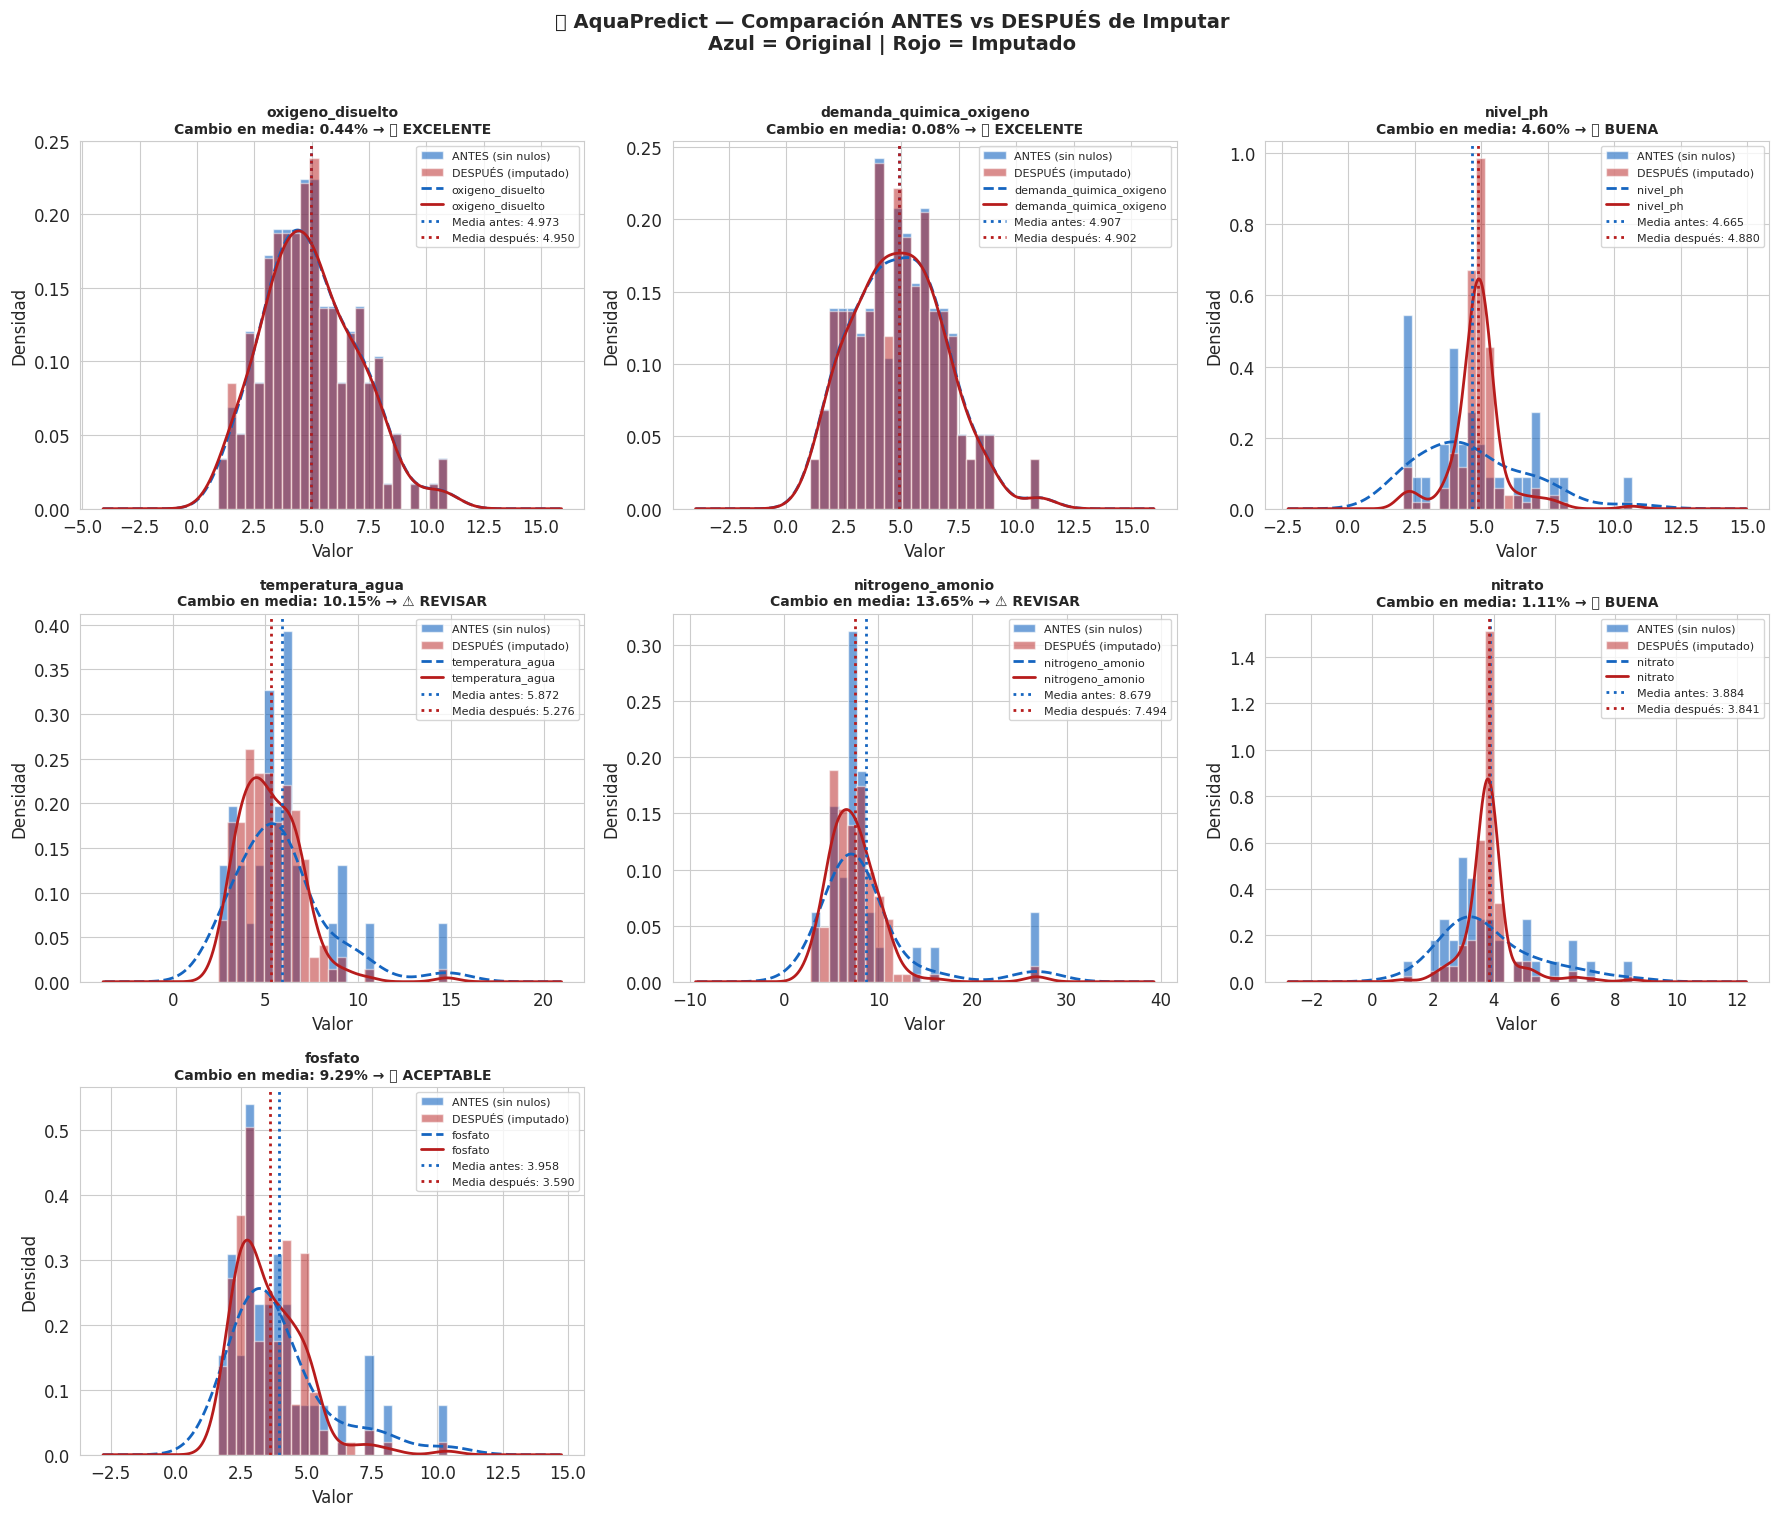

✅ Gráfica guardada: 'comparacion_antes_despues.png'


In [62]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 17: Comparación ANTES vs DESPUÉS de Imputar
# ============================================================

print("=" * 65)
print("  📊 COMPARACIÓN ANTES vs DESPUÉS DE IMPUTAR")
print("=" * 65)

# ── 1. Tabla comparativa estadística ─────────────────────────
# Corregido: Usamos round(valor, 4) en lugar de valor.round(4)
comparacion = pd.DataFrame({
    'Variable'      : cols_numericas,
    'Media_Antes'   : [round(df_train_original[c].mean(), 4)
                        for c in cols_numericas],
    'Media_Despues' : [round(df_train_imputado[c].mean(), 4)
                        for c in cols_numericas],
    'Std_Antes'     : [round(df_train_original[c].std(), 4)
                        for c in cols_numericas],
    'Std_Despues'   : [round(df_train_imputado[c].std(), 4)
                        for c in cols_numericas],
    'Nulos_Antes'   : [df_train_original[c].isnull().sum()
                        for c in cols_numericas],
    'Nulos_Despues' : [df_train_imputado[c].isnull().sum()
                        for c in cols_numericas],
})

# Calcular cambio porcentual en la media
comparacion['Cambio_Media_%'] = (
    abs(comparacion['Media_Despues'] - comparacion['Media_Antes']) /
    (comparacion['Media_Antes'].abs() + 1e-10) * 100
).round(2)

comparacion['Evaluacion'] = comparacion['Cambio_Media_%'].apply(
    lambda x: '✅ EXCELENTE' if x < 1
    else '🟢 BUENA'     if x < 5
    else '🟡 ACEPTABLE'  if x < 10
    else '⚠️ REVISAR'
)

print("\n📋 TABLA COMPARATIVA:")
display(comparacion)

# ── 2. Visualización comparativa ──────────────────────────────
cols_graficar = [c for c in cols_numericas
                  if df_train_original[c].isnull().sum() > 0]

if len(cols_graficar) > 0:
    n_c = min(len(cols_graficar), 3)
    n_r = (len(cols_graficar) + n_c - 1) // n_c

    fig, axes = plt.subplots(n_r, n_c, figsize=(18, n_r * 5))
    fig.suptitle('📊 AquaPredict — Comparación ANTES vs DESPUÉS de Imputar\n'
                 'Azul = Original | Rojo = Imputado',
                 fontsize=14, fontweight='bold', y=1.01)

    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, col in enumerate(cols_graficar):
        ax = axes_flat[i]

        datos_antes   = df_train_original[col].dropna()
        datos_despues = df_train_imputado[col]

        # Histograma ANTES
        ax.hist(datos_antes, bins=25,
                alpha=0.6, color='#1565C0',
                density=True, label='ANTES (sin nulos)',
                edgecolor='white')

        # Histograma DESPUÉS
        ax.hist(datos_despues, bins=25,
                alpha=0.5, color='#B71C1C',
                density=True, label='DESPUÉS (imputado)',
                edgecolor='white')

        # KDE ANTES
        try:
            datos_antes.plot.kde(ax=ax, color='#1565C0',
                                  linewidth=2, linestyle='--')
        except Exception:
            pass

        # KDE DESPUÉS
        try:
            datos_despues.plot.kde(ax=ax, color='#B71C1C',
                                    linewidth=2, linestyle='-')
        except Exception:
            pass

        # Líneas de media
        ax.axvline(datos_antes.mean(), color='#1565C0',
                   linestyle=':', linewidth=2,
                   label=f'Media antes: {datos_antes.mean():.3f}')
        ax.axvline(datos_despues.mean(), color='#B71C1C',
                   linestyle=':', linewidth=2,
                   label=f'Media después: {datos_despues.mean():.3f}')

        cambio = comparacion[comparacion['Variable']==col]['Cambio_Media_%'].values[0]
        estado = comparacion[comparacion['Variable']==col]['Evaluacion'].values[0]

        ax.set_title(f'{col}\nCambio en media: {cambio:.2f}% → {estado}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Valor')
        ax.set_ylabel('Densidad')
        ax.legend(fontsize=8)

    for j in range(len(cols_graficar), len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    plt.savefig('comparacion_antes_despues.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Gráfica guardada: 'comparacion_antes_despues.png'")

## 💾 Paso 18: Guardar los Datos Imputados

### ¿Por qué guardar en este punto?

Guardar los datos imputados es una **buena práctica** porque:

1. ✅ No tenemos que repetir la imputación cada vez que abramos el notebook
2. ✅ Podemos compartir los datos limpios con el equipo
3. ✅ Tenemos un punto de control seguro antes del modelado
4. ✅ Documentamos el proceso de transformación

### Formatos de guardado:

| Formato | Extensión | Ventaja |
|---------|-----------|---------|
| CSV | `.csv` | Universal, fácil de abrir |
| Parquet | `.parquet` | Más eficiente en memoria |
| Excel | `.xlsx` | Fácil para presentaciones |

> 💡 Para este proyecto guardaremos en **CSV**
> por su universalidad y facilidad de uso.

In [63]:
# ============================================================
# ⚙℗ AquaPredict — Grupo 5
# Paso 18: Guardar los Datos Imputados
# ============================================================
import os

print("=" * 60)
print("  ⚙℗ GUARDANDO DATOS IMPUTADOS")
print("=" * 60)

# ── 1. Configurar y crear carpeta si no existe ━━━━━━━━━━━━━━━━
directorio_destino = '/content/drive/MyDrive/AquaPredict'

if not os.path.exists(directorio_destino):
    os.makedirs(directorio_destino)
    print(f"✅ Carpeta creada: {directorio_destino}")
else:
    print(f"⚙℗ La carpeta ya existe: {directorio_destino}")

ruta_train_imp = os.path.join(directorio_destino, 'train_imputado.csv')
ruta_test_imp  = os.path.join(directorio_destino, 'test_imputado.csv')

# ── 2. Guardar archivos ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df_train_imputado.to_csv(ruta_train_imp, index=False)
df_test_imputado.to_csv(ruta_test_imp,  index=False)

# ── 3. Definir variables para el resumen ━━━━━━━━━━━━━━━━━
nulos_test_antes = df_test_original.isnull().sum().sum()

# ── 4. Confirmaci2n ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print(f"""
  ✅ Archivos guardados exitosamente:

  ⚙℗ TRAIN imputado:
     → Ruta    : {ruta_train_imp}
     → Filas   : {df_train_imputado.shape[0]:,}
     → Columnas: {df_train_imputado.shape[1]}
     → Nulos   : {df_train_imputado.isnull().sum().sum()}

  ⚙℗ TEST imputado:
     → Ruta    : {ruta_test_imp}
     → Filas   : {df_test_imputado.shape[0]:,}
     → Columnas: {df_test_imputado.shape[1]}
     → Nulos   : {df_test_imputado.isnull().sum().sum()}
""")

# ── 5. Resumen Final de la Imputaci2n ━━━━━━━━━━━━━━━━
print("=" * 60)
print("  ⚙℗ RESUMEN FINAL DE LA IMPUTACI#N")
print("=" * 60)
print(f"""
  ╔══════════════════════════════════════════════════════╗
  ║     ⚙℗ AquaPredict — Grupo 5                        ║
  ║     Resumen del Proceso de Imputaci#n               ║
  ╠═════════════════════════════════════════════════════╣
  ║                                                      ║
  ║  M#todo usado    : IterativeImputer (MICE)           ║
  ║  Estimador base  : BayesianRidge                     ║
  ║  Iteraciones     : 10                                ║
  ║  Semilla         : 42                                ║
  ║                                                      ║
  ║  TRAIN:                                              ║
  ║  → Nulos antes   : {total_nulos:<6,}                        ║
  ║  → Nulos despu#s : {nulos_despues_train:<6,}                        ║
  ║                                                      ║
  ║  TEST:                                               ║
  ║  → Nulos antes   : {nulos_test_antes:<6,}                        ║
  ║  → Nulos despu#s : {nulos_despues_test:<6,}                        ║
  ║                                                      ║
  ║  Estado : ✅ IMPUTACI#N COMPLETADA                  ║
  ║══════════════════════════════════════════════════════║
""")

print("⚙℗ !Listos para el modelado predictivo!")

  ⚙℗ GUARDANDO DATOS IMPUTADOS
⚙℗ La carpeta ya existe: /content/drive/MyDrive/AquaPredict

  ✅ Archivos guardados exitosamente:

  ⚙℗ TRAIN imputado:
     → Ruta    : /content/drive/MyDrive/AquaPredict/train_imputado.csv
     → Filas   : 147
     → Columnas: 9
     → Nulos   : 0

  ⚙℗ TEST imputado:
     → Ruta    : /content/drive/MyDrive/AquaPredict/test_imputado.csv
     → Filas   : 63
     → Columnas: 9
     → Nulos   : 0

  ⚙℗ RESUMEN FINAL DE LA IMPUTACI#N

  ╔══════════════════════════════════════════════════════╗
  ║     ⚙℗ AquaPredict — Grupo 5                        ║
  ║     Resumen del Proceso de Imputaci#n               ║
  ╠═════════════════════════════════════════════════════╣
  ║                                                      ║
  ║  M#todo usado    : IterativeImputer (MICE)           ║
  ║  Estimador base  : BayesianRidge                     ║
  ║  Iteraciones     : 10                                ║
  ║  Semilla         : 42                                ║
  ║ 